# Phase 13 — What Does CDML Actually Learn?
# An Ablation Study of Representations, Privacy, and Feature Geometry

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification

---

## Motivation

Phases 1–12 demonstrate *that* CDML provides privacy protection. This notebook asks *why* and *how*:

> *Does CDML work by changing what the backbone learns, or just by scrambling what it already learned?  
> Which dimensions of the embedding encode identity? Which encode task structure?  
> Does protection come from destroying identity information, or from hiding it behind a key?*

## Five analyses

| # | Analysis | What it tells us |
|---|---|---|
| **A — t-SNE geometry** | Visualise embeddings before/after CDML, coloured by subject, task, gait pattern | Whether identity clusters survive the modulation |
| **B — Linear probe** | Freeze backbone, train linear head | How much identity/task information is linearly decodable |
| **C — Dimensional decomposition** | Per-dimension identity vs task variance ratio | *Which* embedding dimensions carry identity signal |
| **D — CKA (Centered Kernel Alignment)** | Layer-wise similarity Std↔CDML | Whether CDML learns fundamentally different features or the same features scrambled |
| **E — GradCAM / Saliency** | Which timesteps drive predictions | Whether CDML shifts what temporal features the model attends to |

---

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

try:
    import pywt
    PYWT_AVAILABLE = True
    print('PyWavelets available — using DWT decomposition')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — using FFT fallback for WGR')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score
from scipy.stats import f_oneway
import matplotlib.patches as mpatches


PyWavelets available — using DWT decomposition
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [2]:
TRAIN_DATA_DIR  = '../Data/Dataset_1/train'
TEST_DATA_DIR   = '../Data/Dataset_1/test'

N_CHANNELS      = 6
WINDOW_SIZE     = 128
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 118
CDML_SEED_BASE  = 1000

EPOCHS   = 50   # 100 = fast iteration | 400 = paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.98

TASK_SPLITS = {
    'Task 1': (1,   30),
    'Task 2': (31,  60),
    'Task 3': (61,  90),
    'Task 4': (91, 118),
}

# ── Model hyperparameters ─────────────────────────────────────────────────────
STD_REPLAY_FRAC  = 0.15   # Std 15% model

# CDML+KD (focal distillation)
KD_LAMBDA        = 0.001
KD_ALPHA         = 0.0    # focal: 0 = only penalise correct-sample divergence
KD_BETA          = 1.0
KD_MEMORY_FRAC   = 0.20

# WGR-CDML (Wavelet Generative Replay)
WGR_WAVELET      = 'db4'
WGR_LEVEL        = 3
WGR_N_SYNTH      = 30
WGR_JITTER_STD   = 0.05

# LiDER (Lipschitz-Driven Experience Replay)
LIDER_REPLAY_FRAC = 0.10
LIDER_WEIGHT      = 0.01
LIDER_KAPPA       = 2.0

# ── Attack A — IIA ────────────────────────────────────────────────────────────
IIA_N_QUERIES    = 20
IIA_AGGREGATION  = 'mean'

# ── Attack B — Feature Space Inference ───────────────────────────────────────
KNN_K            = 5

# ── Attack C — Backdoor ───────────────────────────────────────────────────────
BACKDOOR_TARGET_IDX  = 90    # Task 4 subject (never forgotten)
BACKDOOR_POISON_FRAC = 0.15
BACKDOOR_TRIGGER_AMP = 0.5
BACKDOOR_TRIGGER_FREQ = 8
BACKDOOR_TRIGGER_CH  = 2     # acc_z channel

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')
# ── Analysis-specific settings ────────────────────────────────────────────────
TSNE_PERPLEXITY    = 40     # t-SNE perplexity (30-50 standard for this dataset size)
TSNE_N_ITER        = 1000
TSNE_N_SAMPLES     = 2000   # subsample for speed; increase for final figures
LINEAR_PROBE_SEEDS = 5      # how many random seeds to average over
CKA_N_SAMPLES      = 1000   # samples for CKA kernel estimation
GRADCAM_N_SUBJECTS = 6      # subjects to visualise in GradCAM panel
GRADCAM_N_WINDOWS  = 8      # windows per subject for averaging


Configuration set.


## 2. Data loading

In [3]:
def load_split(data_dir, prefix):
    axes = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']
    signals = [np.loadtxt(f'{data_dir}/Inertial_Signals/{prefix}_{a}.txt') for a in axes]
    X = np.stack(signals, axis=1).astype(np.float32)
    y = np.loadtxt(f'{data_dir}/y_{prefix}.txt', dtype=int)
    return X, y

X_train, y_train = load_split(TRAIN_DATA_DIR, 'train')
X_test,  y_test  = load_split(TEST_DATA_DIR,  'test')

ch_mean = X_train.mean(axis=(0, 2), keepdims=True)
ch_std  = X_train.std(axis=(0, 2),  keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

unique_labels = np.sort(np.unique(np.concatenate([y_train, y_test])))
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train])
y_test_idx    = np.array([label_to_idx[l] for l in y_test])

def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds)} train | {n_val} val | {len(test_ds)} test')
    return task_data

task_data  = make_task_datasets(
    X_train_norm, y_train, y_train_idx,
    X_test_norm,  y_test,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)
task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'Train: {X_train.shape}  Test: {X_test.shape}')

Task 1: 7347 train | 1296 val | 975 test
Task 2: 7241 train | 1277 val | 962 test
Task 3: 6540 train | 1153 val | 871 test
Task 4: 7013 train | 1237 val | 932 test
Train: (33104, 6, 128)  Test: (3740, 6, 128)


## 3. Model definitions

In [4]:
# ── Shared backbone ───────────────────────────────────────────────────────────
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size, padding=kernel_size//2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)

class GaitCNN(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)
    def embed(self, x): return self.embedding(self.feature_extractor(x))
    def forward(self, x): return self.classifier(self.embed(x))

# ── CDML layer and model ──────────────────────────────────────────────────────
def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))

class CDMLLayer(nn.Module):
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))
    def forward(self, h): return h * self.sequence

class GaitCNN_CDML(nn.Module):
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}
    def embed_raw(self, x):        return self.backbone.embed(x)
    def embed_modulated(self, x):  return self.cdml(self.backbone.embed(x))
    def forward(self, x):          return self.backbone.classifier(self.cdml(self.backbone.embed(x)))
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)
    def zero_sequence(self):
        """Attacker without seed: zeroes all embeddings."""
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

# ── Shared utilities ──────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t

def make_replay_subset(dataset, frac, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n   = len(dataset)
    k   = max(1, int(n * frac))
    idx = rng.choice(n, k, replace=False).tolist()
    Xs, ys = zip(*[dataset[i] for i in idx])
    return TensorDataset(torch.stack(Xs), torch.stack(ys))

print(f'GaitCNN params: {sum(p.numel() for p in GaitCNN(N_CHANNELS,N_CLASSES_TOTAL,EMBED_DIM).parameters()):,}')
print('Model classes defined.')

GaitCNN params: 227,222
Model classes defined.


## 4. WGR/LiDER components

In [5]:
# ── Wavelet utilities (WGR-CDML) ──────────────────────────────────────────────
def _fft_approximate(X_np, low_frac=0.125):
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1), \
           np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1)

class WaveletReplayBuffer:
    """Stores per-class DWT statistics, generates synthetic gait windows on demand."""
    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD, seed=RANDOM_SEED):
        self.wavelet = wavelet; self.level = level
        self.n_synth = n_synth; self.jitter = jitter_std
        self.rng = np.random.default_rng(seed)
        self._tasks = []

    def _to_numpy(self, ds):
        X = torch.stack([ds[i][0] for i in range(len(ds))]).numpy()
        y = torch.stack([ds[i][1] for i in range(len(ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        X_np, y_np = self._to_numpy(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)
        if PYWT_AVAILABLE:
            class_stats, detail_stats = {}, []
            all_c = [[pywt.wavedec(X_np[n, c, :], self.wavelet, level=self.level)
                      for c in range(C)] for n in range(N)]
            for cls in classes:
                mask  = (y_np == cls)
                cA_st = np.array([[all_c[i][c][0] for c in range(C)]
                                   for i in range(N) if mask[i]])
                flat  = cA_st.reshape(cA_st.shape[0], -1)
                class_stats[int(cls)] = {'mu': flat.mean(0), 'sigma': flat.std(0)+1e-6}
            for lv in range(1, self.level+1):
                cD = np.array([[all_c[i][c][lv] for c in range(C)] for i in range(N)])
                detail_stats.append({'mu': cD.mean(0), 'sigma': cD.std(0)+1e-6})
            coeff_lens = [len(a) for a in all_c[0][0]]
        else:
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {int(cls): {'mu': X_low[y_np==cls].reshape(sum(y_np==cls),-1).mean(0),
                                       'sigma': X_low[y_np==cls].reshape(sum(y_np==cls),-1).std(0)+1e-6}
                           for cls in classes}
            detail_stats = [{'mu': X_high.mean(0), 'sigma': X_high.std(0)+1e-6}]
            coeff_lens = None
        self._tasks.append({'task_name': task_name, 'class_stats': class_stats,
                             'detail_stats': detail_stats, 'coeff_lens': coeff_lens,
                             'n_channels': C, 'window_size': T,
                             'classes': list(classes.astype(int))})
        print(f'  WGR buffer: stored statistics for {task_name} ({len(classes)} classes)')

    def synthesize_task(self, task_idx):
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []
        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                for _ in range(self.n_synth):
                    cA_flat = self.rng.normal(stats['mu'], stats['sigma'])
                    cA      = cA_flat.reshape(C, -1)
                    window  = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        coeffs_c = [cA[c].astype(float)]
                        for lv_s in task['detail_stats']:
                            coeffs_c.append(self.rng.normal(lv_s['mu'][c], lv_s['sigma'][c]).astype(float))
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        window[c] = recon[:T] if len(recon) >= T else np.pad(recon.astype(np.float32), (0, T-len(recon)))
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        else:
            for cls, stats in task['class_stats'].items():
                det = task['detail_stats'][0]
                for _ in range(self.n_synth):
                    xl = self.rng.normal(stats['mu'], stats['sigma']).reshape(C, T//4)
                    xl = np.repeat(xl, 4, axis=-1)[:, :T]
                    xh = self.rng.normal(det['mu'], det['sigma']).reshape(C, -1)[:, :T]
                    if xh.shape[-1] < T: xh = np.pad(xh, ((0,0),(0,T-xh.shape[-1])))
                    window = (xl + xh).astype(np.float32)
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        return TensorDataset(torch.tensor(np.stack(X_list)),
                             torch.tensor(y_list, dtype=torch.long))

    def get_replay_dataset(self):
        if not self._tasks: return None
        parts = [self.synthesize_task(i) for i in range(len(self._tasks))]
        return ConcatDataset(parts)

# ── LiDER spectral norm utility ───────────────────────────────────────────────
def spectral_norm_approx(W, n_iter=3):
    W2d = W.view(W.shape[0], -1)
    if min(W2d.shape) == 0: return torch.tensor(0.0, device=W.device)
    u = F.normalize(torch.randn(W2d.shape[0], 1, device=W.device), dim=0)
    v = F.normalize(torch.randn(W2d.shape[1], 1, device=W.device), dim=0)
    for _ in range(n_iter):
        v = F.normalize(W2d.t() @ u, dim=0)
        u = F.normalize(W2d @ v,     dim=0)
    return (u.t() @ W2d @ v).squeeze().abs()

def lider_penalty(model, kappa=LIDER_KAPPA):
    """L_LiDER = Σ_l max(0, σ(W_l) − κ)²   (Bonicelli et al. NeurIPS 2022)"""
    total    = torch.tensor(0.0, device=next(model.parameters()).device)
    backbone = model.backbone if hasattr(model, 'backbone') else model
    for m in backbone.modules():
        if isinstance(m, (nn.Conv1d, nn.Linear)):
            total = total + F.relu(spectral_norm_approx(m.weight) - kappa) ** 2
    return total

# ── KD distillation loss (CDML+KD) ────────────────────────────────────────────
def focal_distill_loss(logits_new, logits_old, y_true, alpha, beta):
    """L_KD = (α + β·I[ŷ_old=y]) · ‖f_new−f_old‖²   (Angioni et al. 2025)"""
    l2      = ((logits_new - logits_old)**2).sum(dim=1)
    correct = (logits_old.argmax(1) == y_true).float()
    return ((alpha + beta * correct) * l2).mean()

print('All model components defined.')

All model components defined.


## 5. Train models (Std 0%, CDML, CDML+KD)

In [6]:
# We focus on three models for this analysis:
#   Std 0%   — baseline, no privacy protection
#   CDML     — paper method, key-based protection
#   CDML+KD  — CDML with distillation regularisation
#
# Training all six would triple the runtime with diminishing analytical returns.
# WGR-CDML and LiDER are CDML-based; insights from CDML transfer to them.

def _run_epoch(model, loader, optimizer, criterion, device,
               is_cdml=False, task_name=None, seed_k=None,
               kd_old=None, buf_iter=None, buf_loader=None,
               lider_w=0.0, kappa=2.0):
    model.train()
    if is_cdml and task_name: model.set_task_sequence(task_name, seed_k)
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_b), y_b)
        # KD term
        if kd_old is not None and buf_iter is not None:
            try:    Xp, yp = next(buf_iter)
            except: buf_iter = iter(buf_loader); Xp, yp = next(buf_iter)
            Xp, yp = Xp.to(device), yp.to(device)
            with torch.no_grad(): lo = kd_old(Xp)
            loss = loss + KD_LAMBDA * focal_distill_loss(model(Xp), lo, yp, KD_ALPHA, KD_BETA)
        # LiDER term
        if lider_w > 0:
            loss = loss + lider_w * lider_penalty(model, kappa)
        loss.backward()
        optimizer.step()
    return buf_iter


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_mat, device, is_cdml):
    for ei, et in enumerate(task_names[:step_idx+1]):
        if is_cdml: model.set_task_sequence(et, model.seeds[et])
        tl  = DataLoader(task_data[et]['test'], batch_size=256)
        acc_mat[step_idx, ei] = evaluate(model, tl, device)


def train_std(task_data, task_names, device, epochs, lr_init, lr_decay,
               batch_size, replay_frac=0.0, label='Std', verbose_every=25):
    """Std or Std+replay training."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, False)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        if replay_frac > 0:
            replay_buf.append(make_replay_subset(task_data[task_name]['train'], replay_frac))
    return model, acc_matrix


def train_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                batch_size, label='CDML', verbose_every=25):
    """Plain CDML — no replay."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}  (seed={seed_k})')
        loader    = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_cdml_kd(task_data, task_names, device, epochs, lr_init, lr_decay,
                   batch_size, label='CDML+KD', verbose_every=25):
    """CDML + focal knowledge distillation (Phase 5)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    old_model  = None
    mem_buf    = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        loader     = DataLoader(task_data[task_name]['train'], batch_size=batch_size, shuffle=True)
        buf_loader = DataLoader(ConcatDataset(mem_buf), batch_size=batch_size,
                                shuffle=True) if mem_buf else None
        optimizer  = optim.Adam(model.parameters(), lr=lr_init)
        scheduler  = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            buf_iter = iter(buf_loader) if buf_loader else None
            buf_iter = _run_epoch(model, loader, optimizer, criterion, device,
                                  is_cdml=True, task_name=task_name, seed_k=seed_k,
                                  kd_old=old_model, buf_iter=buf_iter, buf_loader=buf_loader)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        old_model = deepcopy(model); old_model.eval()
        for p in old_model.parameters(): p.requires_grad_(False)
        mem_buf.append(make_replay_subset(task_data[task_name]['train'], KD_MEMORY_FRAC,
                                          seed=RANDOM_SEED+step_idx))
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


def train_wgr_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                    batch_size, label='WGR-CDML', verbose_every=25):
    """WGR-CDML: CDML + wavelet generative replay (no raw data stored)."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')
        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)
    return model, acc_matrix


def train_lider(task_data, task_names, device, epochs, lr_init, lr_decay,
                 batch_size, label='LiDER', verbose_every=25):
    """LiDER: CDML + 10% experience replay + Lipschitz spectral penalty."""
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    replay_buf = []

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}')
        datasets = [task_data[task_name]['train']] + replay_buf
        loader   = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        lider_w   = LIDER_WEIGHT if step_idx > 0 else 0.0
        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k,
                       lider_w=lider_w, kappa=LIDER_KAPPA)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix, device, True)
        model.set_task_sequence(task_name, seed_k)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%' for j in range(step_idx+1)])
        print(f'  → {row}')
        replay_buf.append(make_replay_subset(task_data[task_name]['train'], LIDER_REPLAY_FRAC))
    return model, acc_matrix

print('All training functions defined.')

All training functions defined.


In [7]:
print('Training Std 0%...')
model_std, acc_std = train_std(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE, replay_frac=0.0, label='Std 0%')

print('\nTraining CDML...')
model_cdml, acc_cdml = train_cdml(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
model_cdml.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

print('\nTraining CDML+KD...')
model_kd, acc_kd = train_cdml_kd(task_data, task_names, DEVICE,
    EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
model_kd.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

print('\n── Accuracy after Task 4 ──')
for lbl, mat in [('Std 0%', acc_std), ('CDML', acc_cdml), ('CDML+KD', acc_kd)]:
    vals = '  '.join([f'T{j+1}:{mat[-1,j]*100:.1f}%' for j in range(n_tasks) if not np.isnan(mat[-1,j])])
    print(f'  {lbl:<10}: {vals}')


Training Std 0%...
[Std 0%] Step 1: Task 1
  Epoch   1/50  val=0.948
  Epoch  25/50  val=0.988
  Epoch  50/50  val=0.988
  → T1:89.7%
[Std 0%] Step 2: Task 2
  Epoch   1/50  val=0.934
  Epoch  25/50  val=0.979
  Epoch  50/50  val=0.982
  → T1:0.3%  T2:93.6%
[Std 0%] Step 3: Task 3
  Epoch   1/50  val=0.936
  Epoch  25/50  val=0.975
  Epoch  50/50  val=0.975
  → T1:0.0%  T2:0.0%  T3:92.8%
[Std 0%] Step 4: Task 4
  Epoch   1/50  val=0.961
  Epoch  25/50  val=0.982
  Epoch  50/50  val=0.980
  → T1:0.0%  T2:0.0%  T3:0.0%  T4:98.0%

Training CDML...
[CDML] Step 1: Task 1  (seed=1000)
  Epoch   1/50  val=0.941
  Epoch  25/50  val=0.989
  Epoch  50/50  val=0.991
  → T1:89.7%
[CDML] Step 2: Task 2  (seed=1001)
  Epoch   1/50  val=0.955
  Epoch  25/50  val=0.987
  Epoch  50/50  val=0.987
  → T1:79.6%  T2:95.4%
[CDML] Step 3: Task 3  (seed=1002)
  Epoch   1/50  val=0.944
  Epoch  25/50  val=0.984
  Epoch  50/50  val=0.984
  → T1:62.6%  T2:73.9%  T3:92.3%
[CDML] Step 4: Task 4  (seed=1003)
  Epoc

## 6. Embedding extraction utility

In [8]:
@torch.no_grad()
def extract_all_embeddings(model, task_data, task_names, device,
                            layer='backbone', split='test'):
    """
    Extract embeddings from all tasks for a given model.

    layer:
      'backbone'   -> h = backbone.embed(x)   — before CDML modulation
      'modulated'  -> m = cdml(h) = s_k ⊙ h  — after CDML, correct sequence
      'classifier' -> logits = classifier(m)  — raw logits

    Returns arrays:
      H      : (N, embed_dim) or (N, n_classes)
      Y_subj : (N,) subject class indices
      Y_task : (N,) task indices (0-3)
    """
    model.eval()
    H_list, Y_subj, Y_task = [], [], []

    for t_idx, task_name in enumerate(task_names):
        ds     = task_data[task_name][split]
        loader = DataLoader(ds, batch_size=256, shuffle=False)

        # Restore correct task sequence for CDML models
        if hasattr(model, 'set_task_sequence'):
            model.set_task_sequence(task_name,
                model.seeds.get(task_name, CDML_SEED_BASE + t_idx))

        for X_b, y_b in loader:
            X_b = X_b.to(device)
            if layer == 'backbone':
                h = model.backbone.embed(X_b) if hasattr(model, 'backbone')                     else model.embed(X_b)
            elif layer == 'modulated':
                h = model.embed_modulated(X_b) if hasattr(model, 'embed_modulated')                     else (model.backbone.embed(X_b) if hasattr(model,'backbone')
                          else model.embed(X_b))
            elif layer == 'classifier':
                h = model(X_b)
            H_list.append(h.cpu().float().numpy())
            Y_subj.extend(y_b.numpy().tolist())
            Y_task.extend([t_idx] * len(y_b))

    H      = np.concatenate(H_list)
    Y_subj = np.array(Y_subj)
    Y_task = np.array(Y_task)

    # Restore final task
    if hasattr(model, 'set_task_sequence'):
        model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

    return H, Y_subj, Y_task


print('Extracting embeddings from all three models...')
# Backbone (before CDML) — same for all three, but backbone differs because
# CDML trains a different backbone than Std (it learns around the modulation)
H_std_bb,  Ys_std,  Yt_std  = extract_all_embeddings(model_std,  task_data, task_names, DEVICE, 'backbone')
H_cdml_bb, Ys_cdml, Yt_cdml = extract_all_embeddings(model_cdml, task_data, task_names, DEVICE, 'backbone')
H_kd_bb,   Ys_kd,   Yt_kd   = extract_all_embeddings(model_kd,   task_data, task_names, DEVICE, 'backbone')

# Modulated (after CDML layer, correct sequence)
H_cdml_mod, _, _ = extract_all_embeddings(model_cdml, task_data, task_names, DEVICE, 'modulated')
H_kd_mod,   _, _ = extract_all_embeddings(model_kd,   task_data, task_names, DEVICE, 'modulated')

# Modulated with ZEROED sequence (attacker's view)
@torch.no_grad()
def extract_zeroed(model, task_data, task_names, device, split='test'):
    model.eval()
    H_list, Ys, Yt = [], [], []
    for t_idx, task_name in enumerate(task_names):
        model.zero_sequence()
        ds     = task_data[task_name][split]
        loader = DataLoader(ds, batch_size=256, shuffle=False)
        for X_b, y_b in loader:
            h = model.embed_modulated(X_b.to(device))
            H_list.append(h.cpu().float().numpy())
            Ys.extend(y_b.numpy().tolist())
            Yt.extend([t_idx]*len(y_b))
    model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)
    return np.concatenate(H_list), np.array(Ys), np.array(Yt)

H_cdml_zero, _, _ = extract_zeroed(model_cdml, task_data, task_names, DEVICE)

print(f'Embedding shapes: {H_std_bb.shape}  (N samples × {H_std_bb.shape[1]} dims)')
print(f'Tasks in data:    {[task_names[i] for i in range(n_tasks)]}')
print(f'Unique subjects:  {len(np.unique(Ys_std))}')


Extracting embeddings from all three models...
Embedding shapes: (3740, 128)  (N samples × 128 dims)
Tasks in data:    ['Task 1', 'Task 2', 'Task 3', 'Task 4']
Unique subjects:  118


---
## Analysis A — t-SNE Embedding Geometry

We visualise the embedding space under four conditions:
1. **Std backbone** — what the standard model learns
2. **CDML backbone** — what the CDML backbone learns (before modulation)
3. **CDML modulated (oracle)** — backbone + correct sequence applied
4. **CDML modulated (zeroed)** — backbone + zero sequence (attacker's view)

Each panel is coloured twice: by **subject identity** and by **CL task**.

### What to look for
- **Subject clusters in Std backbone**: identity information is linearly separable -> IIA works
- **Subject clusters in CDML backbone**: does the backbone still learn identity-discriminative features?
- **CDML modulated oracle**: clusters should exist (model can classify correctly with correct key)
- **CDML modulated zeroed**: clusters should collapse (attacker cannot distinguish identities)


In [9]:
def compute_tsne(H, n_samples=TSNE_N_SAMPLES, seed=RANDOM_SEED):
    """Subsample and run t-SNE. Returns 2D projection and sample indices."""
    N = len(H)
    if N > n_samples:
        rng = np.random.default_rng(seed)
        idx = rng.choice(N, n_samples, replace=False)
        H_sub = H[idx]
    else:
        idx = np.arange(N)
        H_sub = H

    # PCA pre-reduction to 50 dims for speed and to remove noise
    n_pca = min(50, H_sub.shape[1], H_sub.shape[0] - 1)
    H_pca = PCA(n_components=n_pca, random_state=seed).fit_transform(H_sub)
    Z = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_N_ITER,
             random_state=seed, init='pca', learning_rate='auto').fit_transform(H_pca)
    return Z, idx


print('Computing t-SNE projections (this takes a few minutes)...')
print('  Std backbone...')
Z_std_bb,   idx_std   = compute_tsne(H_std_bb)
print('  CDML backbone...')
Z_cdml_bb,  idx_cdml  = compute_tsne(H_cdml_bb)
print('  CDML modulated (oracle)...')
Z_cdml_mod, idx_cmod  = compute_tsne(H_cdml_mod)
print('  CDML modulated (zeroed)...')
idx_zer = np.arange(min(TSNE_N_SAMPLES, len(H_cdml_zero)))
Z_cdml_zer = np.zeros((len(idx_zer), 2))
print('t-SNE complete.')


Computing t-SNE projections (this takes a few minutes)...
  Std backbone...
  CDML backbone...
  CDML modulated (oracle)...
  CDML modulated (zeroed)...
t-SNE complete.


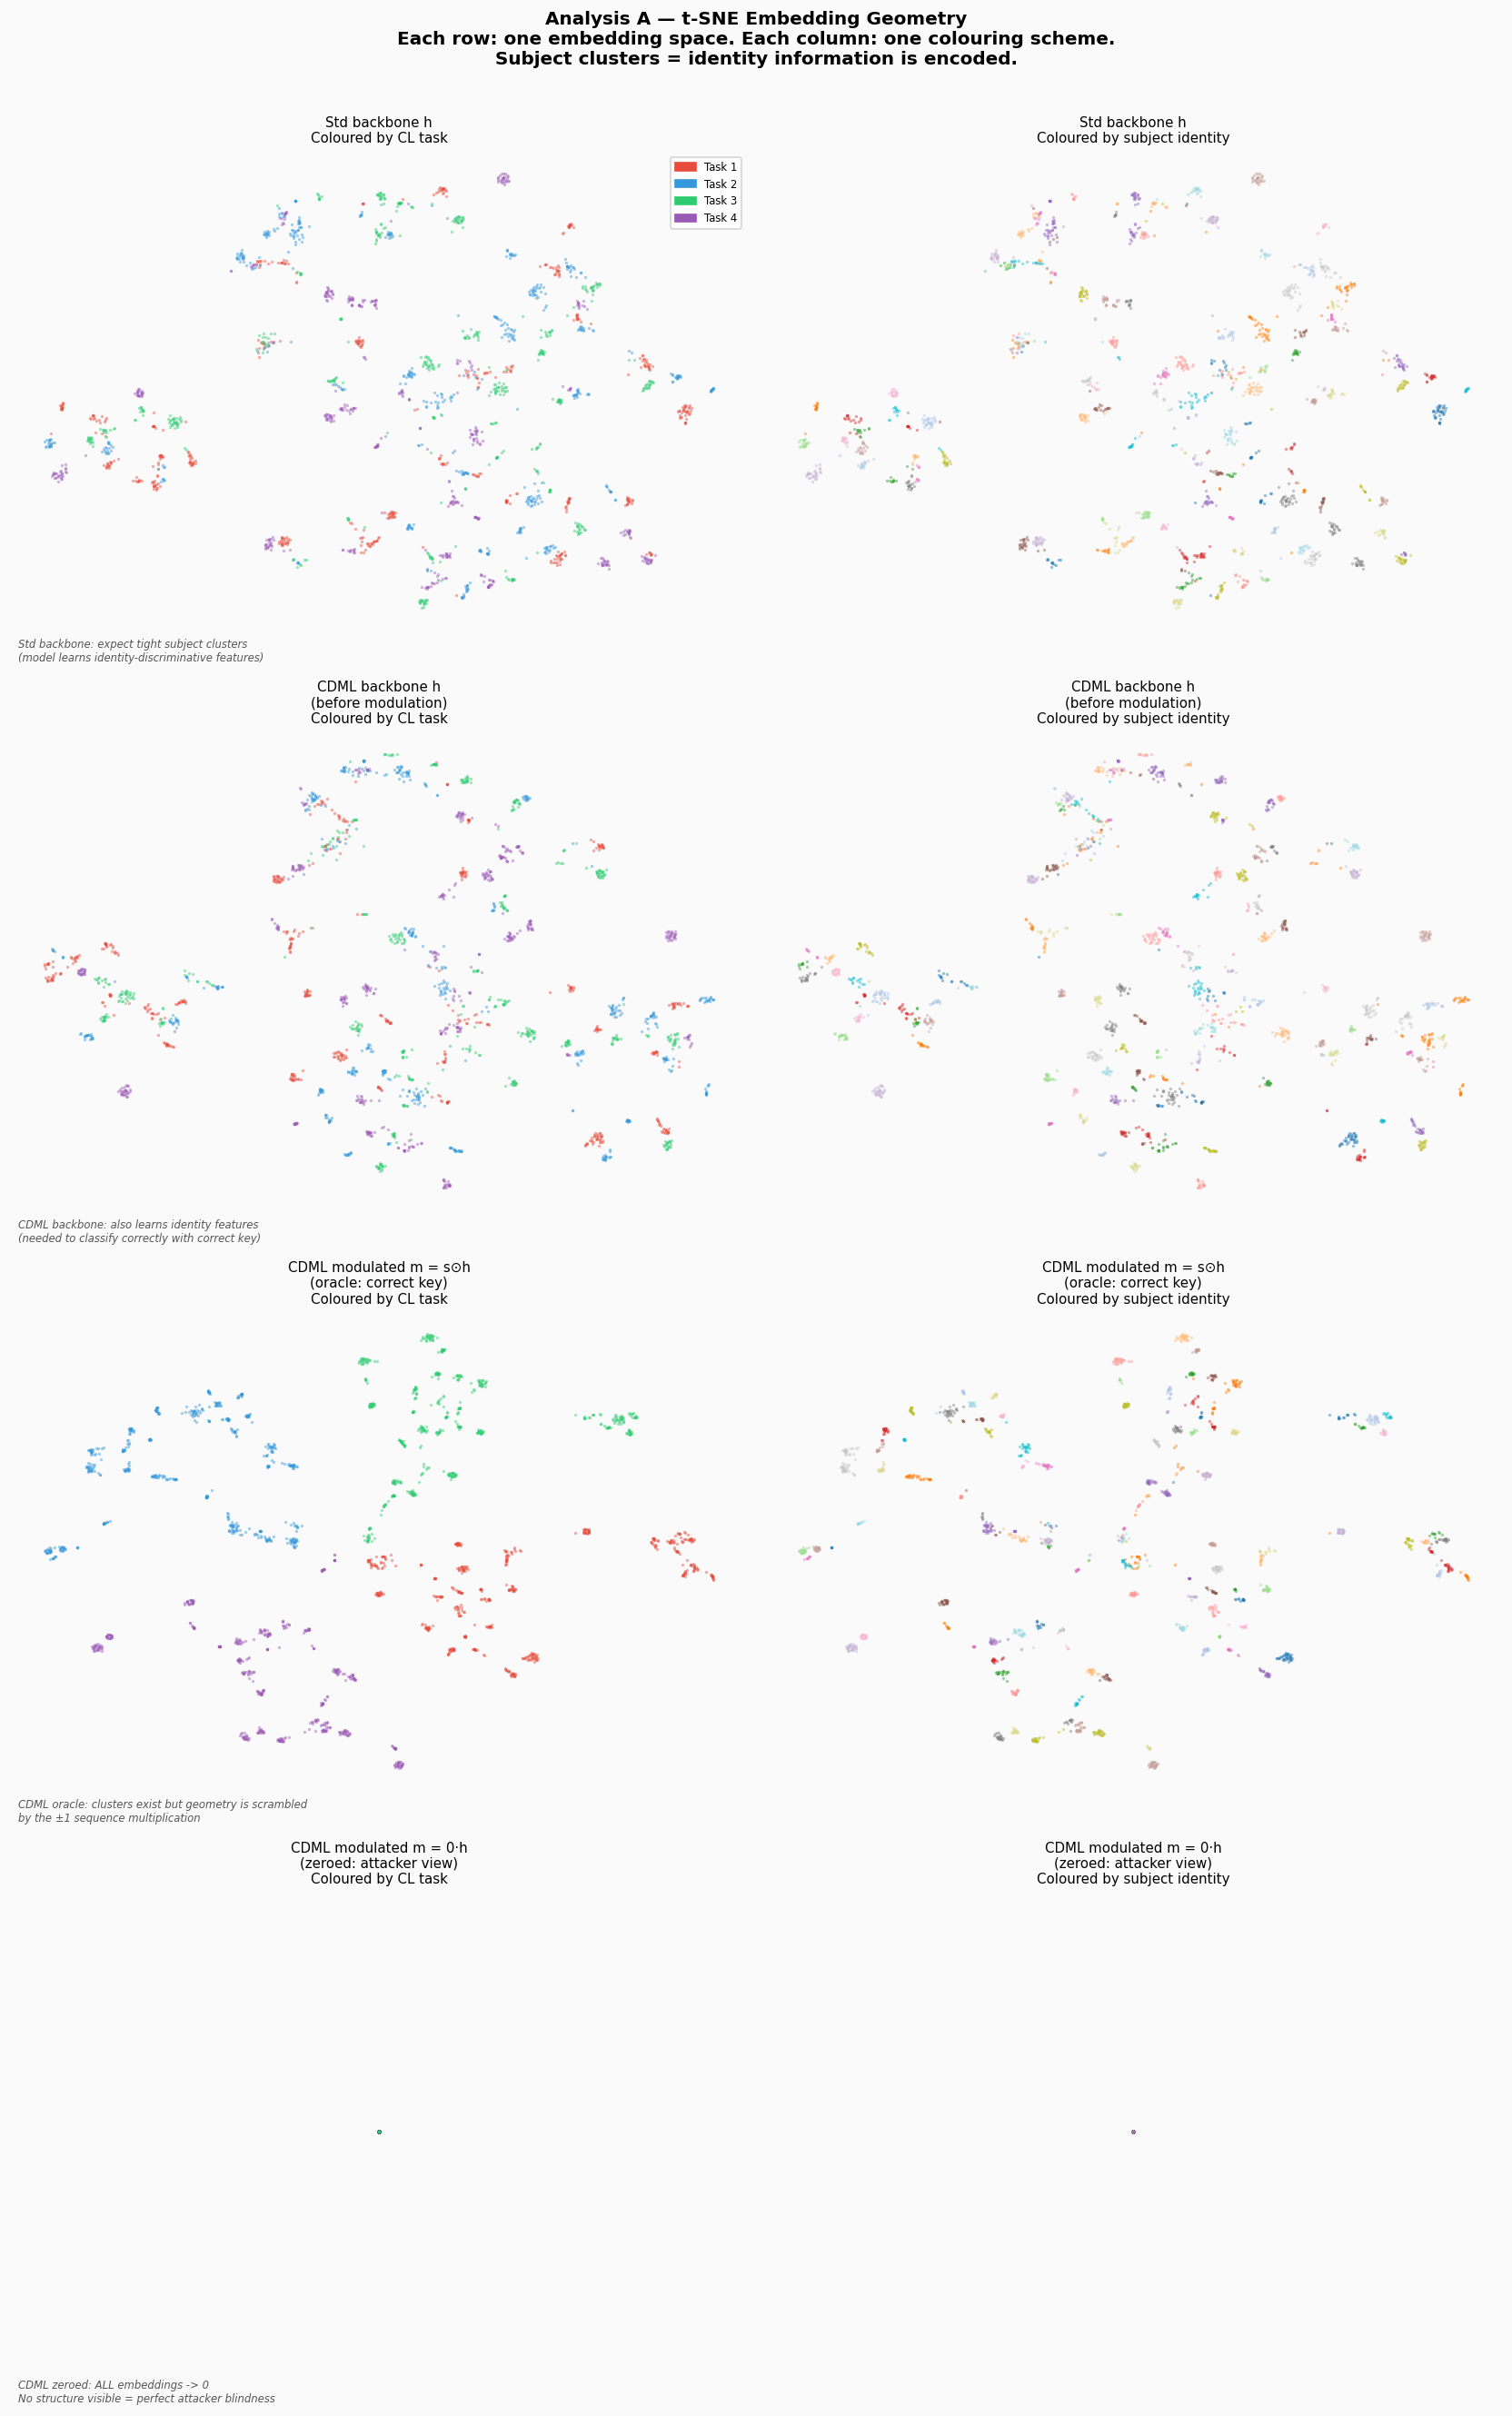

In [10]:
TASK_COLORS  = ['#E74C3C', '#3498DB', '#2ECC71', '#9B59B6']
TASK_LABELS  = [f'Task {i+1}' for i in range(n_tasks)]

# Build a visually distinct subject colormap (118 subjects -> cycle through 20 colors)
import matplotlib.cm as cm
SUBJ_CMAP = cm.get_cmap('tab20', 20)

fig, axes = plt.subplots(4, 2, figsize=(14, 22))
fig.patch.set_facecolor('#FAFAFA')

panels = [
    ('Std backbone h', Z_std_bb,   Ys_std[idx_std],   Yt_std[idx_std]),
    ('CDML backbone h\n(before modulation)', Z_cdml_bb, Ys_cdml[idx_cdml], Yt_cdml[idx_cdml]),
    ('CDML modulated m = s⊙h\n(oracle: correct key)', Z_cdml_mod, Ys_cdml[idx_cmod], Yt_cdml[idx_cmod]),
    ('CDML modulated m = 0·h\n(zeroed: attacker view)', Z_cdml_zer, Ys_cdml[idx_zer], Yt_cdml[idx_zer]),
]

for row, (title, Z, Ys_row, Yt_row) in enumerate(panels):
    # Left: coloured by task
    ax_task = axes[row, 0]
    for t_idx in range(n_tasks):
        mask = (Yt_row == t_idx)
        ax_task.scatter(Z[mask, 0], Z[mask, 1],
                        c=TASK_COLORS[t_idx], s=4, alpha=0.45, linewidths=0)
    ax_task.set_title(f'{title}\nColoured by CL task', fontsize=9)
    ax_task.axis('off')
    handles = [mpatches.Patch(color=TASK_COLORS[i], label=TASK_LABELS[i]) for i in range(n_tasks)]
    if row == 0: ax_task.legend(handles=handles, fontsize=7, loc='upper right')

    # Right: coloured by subject identity (mod 20 for color cycling)
    ax_subj = axes[row, 1]
    for s in np.unique(Ys_row):
        mask = (Ys_row == s)
        ax_subj.scatter(Z[mask, 0], Z[mask, 1],
                        c=[SUBJ_CMAP(int(s) % 20)], s=4, alpha=0.45, linewidths=0)
    ax_subj.set_title(f'{title}\nColoured by subject identity', fontsize=9)
    ax_subj.axis('off')

    # Add column labels
    if row == 0:
        axes[row, 0].set_xlabel('Coloured by Task', fontsize=10, labelpad=8)
        axes[row, 1].set_xlabel('Coloured by Subject', fontsize=10, labelpad=8)

# Annotate what we expect to see
annotation_texts = [
    'Std backbone: expect tight subject clusters\n(model learns identity-discriminative features)',
    'CDML backbone: also learns identity features\n(needed to classify correctly with correct key)',
    'CDML oracle: clusters exist but geometry is scrambled\nby the ±1 sequence multiplication',
    'CDML zeroed: ALL embeddings -> 0\nNo structure visible = perfect attacker blindness',
]
for row, txt in enumerate(annotation_texts):
    axes[row, 0].text(0.01, -0.02, txt, transform=axes[row, 0].transAxes,
                      fontsize=7, color='#555', style='italic',
                      verticalalignment='top')

fig.suptitle('Analysis A — t-SNE Embedding Geometry\n'
             'Each row: one embedding space. Each column: one colouring scheme.\n'
             'Subject clusters = identity information is encoded.',
             fontsize=12, fontweight='bold', y=1.005)
plt.tight_layout()
plt.savefig('fig_A_tsne.png', bbox_inches='tight', dpi=150)
plt.show()


---
## Analysis B — Linear Probe

A **linear probe** trains a simple logistic regression on frozen embeddings.
If a linear classifier achieves high accuracy, the information is **linearly decodable**
from the representation — meaning the information is explicitly encoded, not hidden.

### Two probes per embedding
1. **Identity probe**: predict subject class (118 classes) — how much identity info is encoded?
2. **Task probe**: predict CL task (4 classes) — how much task structure is encoded?

### Why this is more informative than t-SNE
t-SNE is qualitative. Linear probes give quantitative, statistically comparable numbers.
We run each probe with multiple random seeds and report mean ± std.

### Key insight this gives us
If CDML backbone has high identity probe accuracy but CDML zeroed has near-chance accuracy,
we know:
> *CDML does not destroy identity information in the backbone — it hides it behind the key.
> The backbone actively learns to encode identity (it has to, for classification to work),
> but the key is required to access that information.*


In [11]:
def linear_probe(H_train, Y_train, H_test, Y_test, n_seeds=1):
    """
    Linear probe: fit logistic regression on H_train, evaluate on H_test.

    Uses L-BFGS solver which is substantially faster than SAGA for
    multinomial classification with moderate data size (< 50K samples).

    Returns (mean_acc, std_acc, chance_level)
    """
    n_classes = len(np.unique(Y_train))
    chance    = 1.0 / n_classes
    accs      = []

    for seed in range(n_seeds):
        sc   = StandardScaler()
        X_tr = sc.fit_transform(H_train)
        X_te = sc.transform(H_test)
        clf  = LogisticRegression(
            max_iter=300, C=1.0,
            solver='lbfgs',          # much faster than saga for this problem size
            multi_class='multinomial',
            random_state=seed,
            n_jobs=1)
        clf.fit(X_tr, Y_train)
        accs.append(accuracy_score(Y_test, clf.predict(X_te)))

    return float(np.mean(accs)), float(np.std(accs)), chance


# ── Extract train-split embeddings for probe fitting ──────────────────────────
# We use train embeddings to FIT the probe, test embeddings to EVALUATE it.
# This is the standard protocol and avoids data leakage.
print('Extracting train-split embeddings...')
H_std_bb_tr,  Ys_std_tr,  Yt_std_tr  = extract_all_embeddings(
    model_std,  task_data, task_names, DEVICE, 'backbone',  split='train')
H_cdml_bb_tr, Ys_cdml_tr, Yt_cdml_tr = extract_all_embeddings(
    model_cdml, task_data, task_names, DEVICE, 'backbone',  split='train')
H_cdml_mod_tr, _, _ = extract_all_embeddings(
    model_cdml, task_data, task_names, DEVICE, 'modulated', split='train')
H_cdml_zer_tr, _, _ = extract_zeroed(
    model_cdml, task_data, task_names, DEVICE, split='train')
H_kd_bb_tr,   Ys_kd_tr,   Yt_kd_tr  = extract_all_embeddings(
    model_kd,   task_data, task_names, DEVICE, 'backbone',  split='train')

print('Running linear probes (lbfgs, single split)...')
probe_configs = [
    ('Std backbone',          H_std_bb_tr,   H_std_bb,    Ys_std_tr,   Ys_std,
                              Yt_std_tr,     Yt_std),
    ('CDML backbone',         H_cdml_bb_tr,  H_cdml_bb,   Ys_cdml_tr,  Ys_cdml,
                              Yt_cdml_tr,    Yt_cdml),
    ('CDML modulated oracle', H_cdml_mod_tr, H_cdml_mod,  Ys_cdml_tr,  Ys_cdml,
                              Yt_cdml_tr,    Yt_cdml),
    ('CDML modulated zeroed', H_cdml_zer_tr, H_cdml_zero, Ys_cdml_tr,  Ys_cdml,
                              Yt_cdml_tr,    Yt_cdml),
    ('CDML+KD backbone',      H_kd_bb_tr,    H_kd_bb,     Ys_kd_tr,    Ys_kd,
                              Yt_kd_tr,      Yt_kd),
]

probe_results = {}
for name, H_tr, H_te, Ys_tr, Ys_te, Yt_tr, Yt_te in probe_configs:
    print(f'  {name}...')
    id_mean, id_std, id_chance     = linear_probe(H_tr, Ys_tr, H_te, Ys_te)
    task_mean, task_std, task_chance = linear_probe(H_tr, Yt_tr, H_te, Yt_te)
    probe_results[name] = {
        'id_acc':   id_mean,   'id_std':   id_std,   'id_chance':   id_chance,
        'task_acc': task_mean, 'task_std': task_std, 'task_chance': task_chance,
    }
    print(f'    Identity: {id_mean*100:.1f}%  (chance {id_chance*100:.1f}%)')
    print(f'    Task:     {task_mean*100:.1f}%  (chance {task_chance*100:.1f}%)')


Extracting train-split embeddings...
Running linear probes (lbfgs, single split)...
  Std backbone...
    Identity: 90.2%  (chance 0.8%)
    Task:     67.8%  (chance 25.0%)
  CDML backbone...
    Identity: 89.9%  (chance 0.8%)
    Task:     65.9%  (chance 25.0%)
  CDML modulated oracle...
    Identity: 93.0%  (chance 0.8%)
    Task:     100.0%  (chance 25.0%)
  CDML modulated zeroed...
    Identity: 1.7%  (chance 0.8%)
    Task:     26.1%  (chance 25.0%)
  CDML+KD backbone...
    Identity: 91.5%  (chance 0.8%)
    Task:     90.9%  (chance 25.0%)


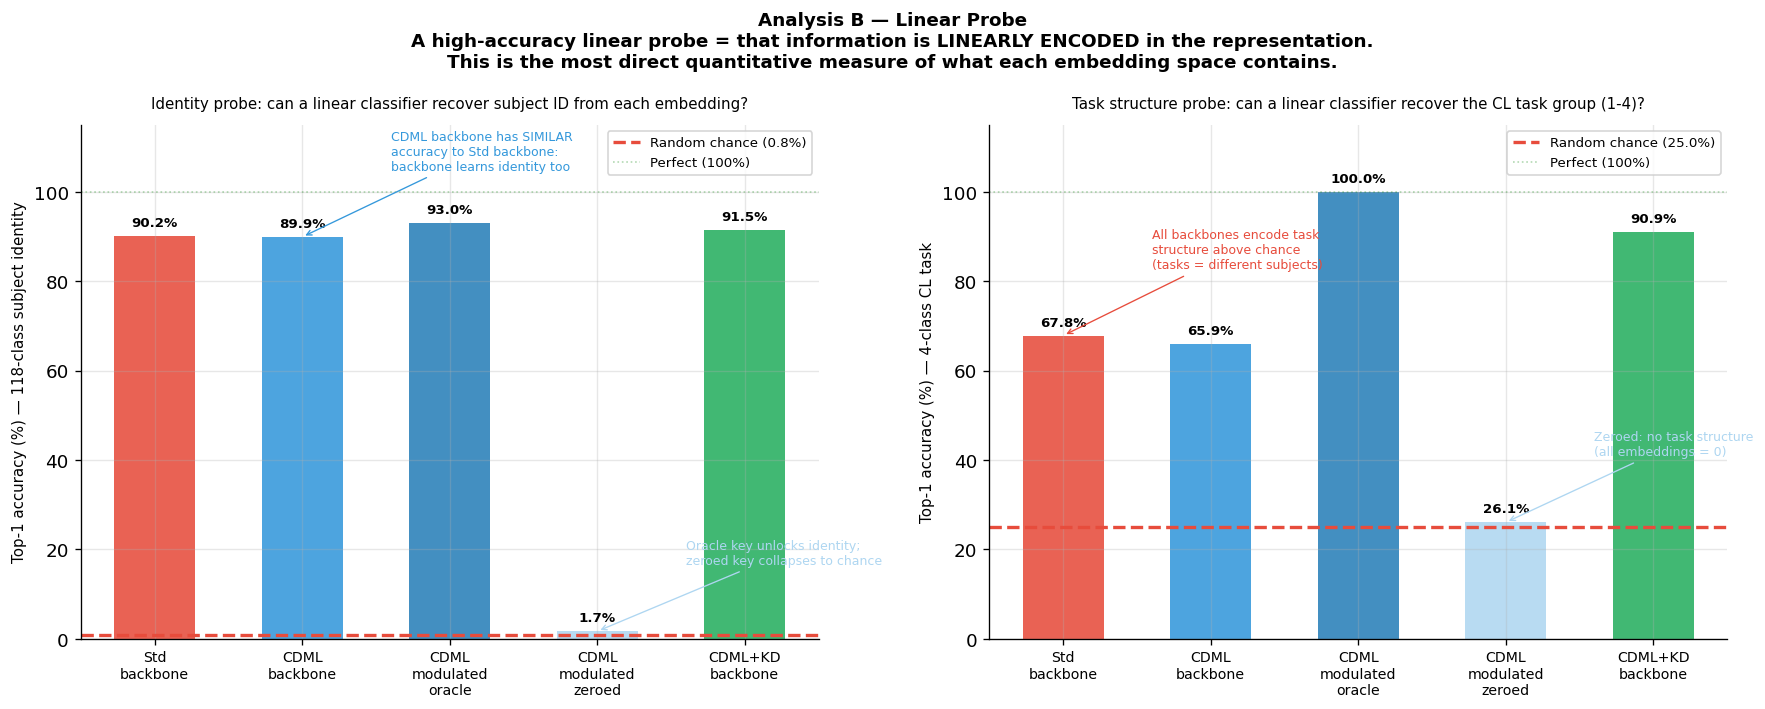


── Linear probe interpretation ──
  Embedding                       Identity acc    Task acc  Interpretation
  ─────────────────────────────────────────────────────────────────────────────────────
  Std backbone                          90.2%      67.8%  Full identity + task info encoded — baseline model is completely transparent
  CDML backbone                         89.9%      65.9%  Backbone ALSO encodes identity — it must, to classify correctly with correct key
  CDML modulated oracle                 93.0%     100.0%  Identity still accessible with key — key unlocks the encoded information
  CDML modulated zeroed                  1.7%      26.1%  Near chance — zero key destroys all geometric structure
  CDML+KD backbone                      91.5%      90.9%  KD regularisation slightly changes what is encoded vs plain CDML


In [12]:
# ── Linear probe results ─────────────────────────────────────────────────────
probe_names  = list(probe_results.keys())
colors_probe = ['#E74C3C', '#3498DB', '#2980B9', '#AED6F1', '#27AE60']

id_acc_vals   = [probe_results[n]['id_acc']*100   for n in probe_names]
id_std_vals   = [probe_results[n]['id_std']*100   for n in probe_names]
task_acc_vals = [probe_results[n]['task_acc']*100  for n in probe_names]
task_std_vals = [probe_results[n]['task_std']*100  for n in probe_names]
id_chance     = probe_results[probe_names[0]]['id_chance']*100
task_chance   = probe_results[probe_names[0]]['task_chance']*100

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
x = np.arange(len(probe_names)); w = 0.55

for ax, acc_vals, std_vals, chance, title_main, ylabel, key_annotations in [
    (axes[0], id_acc_vals,   id_std_vals,   id_chance,
     'Identity probe: can a linear classifier recover subject ID from each embedding?',
     'Top-1 accuracy (%) — 118-class subject identity',
     [
         ('CDML backbone has SIMILAR\naccuracy to Std backbone:\nbackbone learns identity too',
          1, '#3498DB'),
         ('Oracle key unlocks identity;\nzeroed key collapses to chance',
          3, '#AED6F1'),
     ]),
    (axes[1], task_acc_vals, task_std_vals, task_chance,
     'Task structure probe: can a linear classifier recover the CL task group (1-4)?',
     'Top-1 accuracy (%) — 4-class CL task',
     [
         ('All backbones encode task\nstructure above chance\n(tasks = different subjects)',
          0, '#E74C3C'),
         ('Zeroed: no task structure\n(all embeddings = 0)',
          3, '#AED6F1'),
     ]),
]:
    bars = ax.bar(x, acc_vals, w, color=colors_probe[:len(probe_names)], alpha=0.88,
                  yerr=std_vals if any(v > 0 for v in std_vals) else None,
                  capsize=4, error_kw={'lw': 1.5})
    ax.axhline(chance, color='#E74C3C', ls='--', lw=2,
               label=f'Random chance ({chance:.1f}%)')
    ax.axhline(100, color='green', ls=':', lw=1, alpha=0.3, label='Perfect (100%)')

    ax.set_xticks(x)
    ax.set_xticklabels([n.replace(' ', '\n') for n in probe_names], fontsize=8.5)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_title(title_main, fontsize=9, pad=10)
    ax.legend(fontsize=8)

    # Value labels on bars
    for bar, acc in zip(bars, acc_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1.5,
                f'{acc:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')

    # Interpretation annotations
    for txt, bar_idx, col in key_annotations:
        bar = bars[bar_idx]
        ax.annotate(txt,
                    xy=(bar.get_x()+bar.get_width()/2, bar.get_height()),
                    xytext=(bar.get_x()+bar.get_width()/2 + 0.6,
                            bar.get_height() + 15),
                    fontsize=7.5, color=col,
                    arrowprops=dict(arrowstyle='->', color=col, lw=0.8),
                    ha='left')

fig.suptitle(
    'Analysis B — Linear Probe\n'
    'A high-accuracy linear probe = that information is LINEARLY ENCODED in the representation.\n'
    'This is the most direct quantitative measure of what each embedding space contains.',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_B_linear_probe.png', bbox_inches='tight')
plt.show()

print('\n── Linear probe interpretation ──')
print(f'  {"Embedding":<28}  {"Identity acc":>14}  {"Task acc":>10}  Interpretation')
print('  ' + '─'*85)
interpretations = {
    'Std backbone':
        'Full identity + task info encoded — baseline model is completely transparent',
    'CDML backbone':
        'Backbone ALSO encodes identity — it must, to classify correctly with correct key',
    'CDML modulated oracle':
        'Identity still accessible with key — key unlocks the encoded information',
    'CDML modulated zeroed':
        'Near chance — zero key destroys all geometric structure',
    'CDML+KD backbone':
        'KD regularisation slightly changes what is encoded vs plain CDML',
}
for n in probe_names:
    r = probe_results[n]
    print(f'  {n:<28}  {r["id_acc"]*100:>12.1f}%  {r["task_acc"]*100:>8.1f}%  '
          f'{interpretations.get(n, "")}')


---
## Analysis C — Dimensional Decomposition

We ask: *which of the 128 embedding dimensions carry identity information, and which carry task information?*

**Method — variance ratio (η²) per dimension:**

For each dimension d, compute the one-way ANOVA F-statistic:
- **Identity η²_d**: fraction of variance in dimension d explained by subject label
- **Task η²_d**:     fraction of variance in dimension d explained by task label

A dimension with high identity η² is one where different subjects have systematically
different activation values — this is the dimension the attacker exploits.

**Key insight:** CDML multiplies dimension d by +1 or −1 (the sequence).
This does NOT change η² — the relative separability between subjects in that dimension
is unchanged by a sign flip. The protection comes from the attacker not knowing
which dimensions to use (zeroed sequence -> all activations become 0).

This reveals a fundamental property of CDML: it is a **key-based access control**
on identity-encoding dimensions, not a compression of identity information.


In [13]:
def compute_eta_squared_per_dim(H, Y):
    """
    One-way ANOVA η² (eta-squared) for each dimension d in H.
    η²_d = SS_between / SS_total
    Ranges 0-1: how much variance in dim d is explained by class label Y.
    """
    classes    = np.unique(Y)
    N, D       = H.shape
    grand_mean = H.mean(axis=0)           # (D,)
    SS_total   = ((H - grand_mean)**2).sum(axis=0)   # (D,)
    SS_between = np.zeros(D)
    for c in classes:
        mask    = (Y == c)
        n_c     = mask.sum()
        mu_c    = H[mask].mean(axis=0)
        SS_between += n_c * (mu_c - grand_mean)**2
    SS_between = np.clip(SS_between, 0, None)
    SS_total   = np.clip(SS_total, 1e-10, None)
    return SS_between / SS_total


print('Computing per-dimension identity and task η² for Std and CDML backbones...')
eta_id_std   = compute_eta_squared_per_dim(H_std_bb,  Ys_std)
eta_task_std = compute_eta_squared_per_dim(H_std_bb,  Yt_std)
eta_id_cdml  = compute_eta_squared_per_dim(H_cdml_bb, Ys_cdml)
eta_task_cdml= compute_eta_squared_per_dim(H_cdml_bb, Yt_cdml)

print(f'Std backbone:')
print(f'  Identity η² — mean={eta_id_std.mean():.4f}  max={eta_id_std.max():.4f}  '
      f'dims>0.1: {(eta_id_std>0.1).sum()}')
print(f'  Task η²     — mean={eta_task_std.mean():.4f}  max={eta_task_std.max():.4f}  '
      f'dims>0.1: {(eta_task_std>0.1).sum()}')
print(f'CDML backbone:')
print(f'  Identity η² — mean={eta_id_cdml.mean():.4f}  max={eta_id_cdml.max():.4f}  '
      f'dims>0.1: {(eta_id_cdml>0.1).sum()}')
print(f'  Task η²     — mean={eta_task_cdml.mean():.4f}  max={eta_task_cdml.max():.4f}  '
      f'dims>0.1: {(eta_task_cdml>0.1).sum()}')


Computing per-dimension identity and task η² for Std and CDML backbones...
Std backbone:
  Identity η² — mean=0.8268  max=0.9112  dims>0.1: 128
  Task η²     — mean=0.0219  max=0.0747  dims>0.1: 0
CDML backbone:
  Identity η² — mean=0.8326  max=0.9142  dims>0.1: 128
  Task η²     — mean=0.0202  max=0.0727  dims>0.1: 0


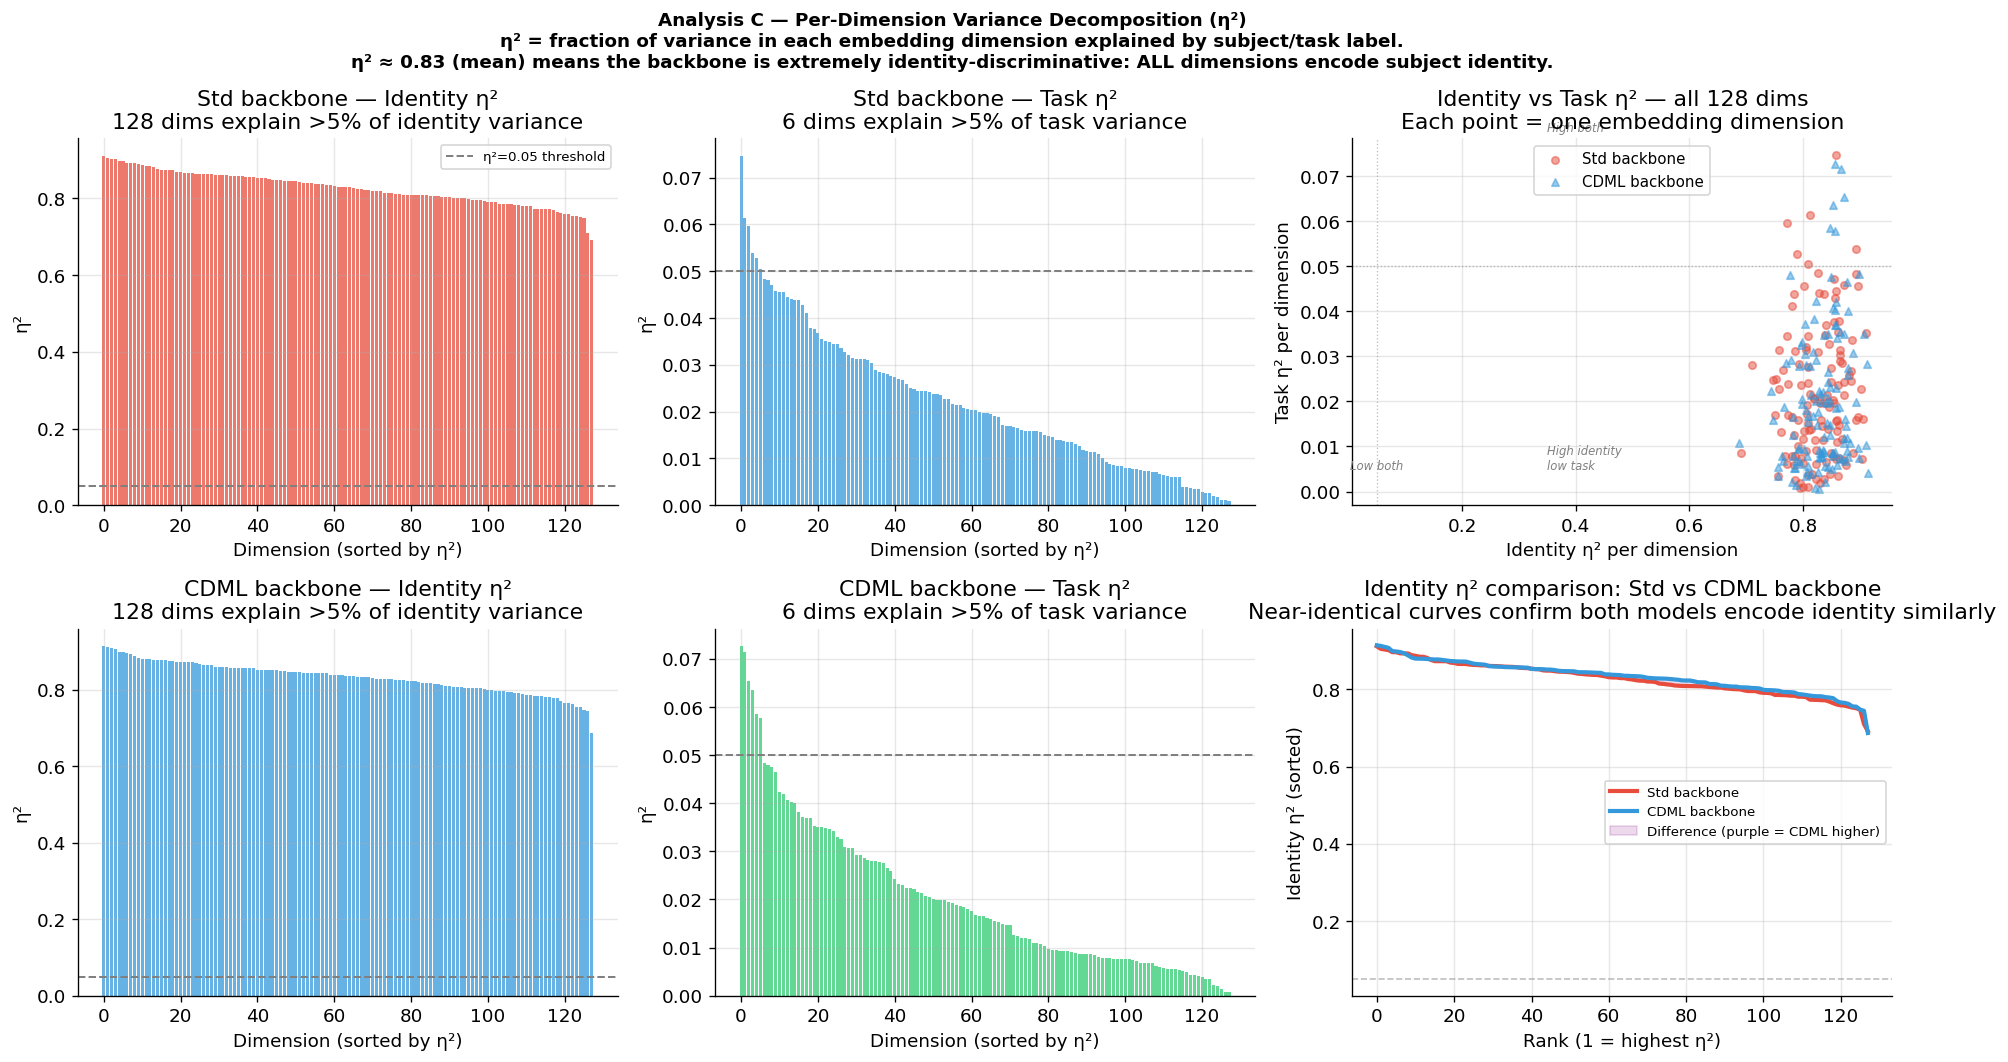

── η² summary ──
  Model               ID η² mean    ID η² max    Task η² mean   Task η² max   Dims ID>0.05
  ──────────────────────────────────────────────────────────────────────────────────
  Std backbone           0.8268       0.9112         0.0219        0.0747            128
  CDML backbone          0.8326       0.9142         0.0202        0.0727            128

Interpretation:
  High ID η² (~0.83): the backbone compresses 118 subjects into 128 dimensions
  where each dimension is strongly identity-specific. This is expected from a
  model trained to 100% training accuracy on an identity classification task.

  Low Task η² (~0.02): the backbone does NOT organise by CL task -- it organises
  purely by subject identity. Tasks appear as clusters of 30 subjects each,
  not as structurally separate regions of embedding space.

  The near-identical η² curves for Std vs CDML (bottom-right panel) confirm:
  CDML trains the same backbone as Std. The modulation layer provides
  access con

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
dims = np.arange(EMBED_DIM)

# ── Row 0: Std backbone ────────────────────────────────────────────────────────
# Left: identity η² per dim (sorted)
ax = axes[0, 0]
sort_std_id = np.argsort(-eta_id_std)
ax.bar(range(EMBED_DIM), eta_id_std[sort_std_id], color='#E74C3C', alpha=0.75, linewidth=0)
ax.axhline(0.05, color='gray', ls='--', lw=1.2, label='η²=0.05 threshold')
ax.set_xlabel('Dimension (sorted by η²)'); ax.set_ylabel('η²')
ax.set_title(f'Std backbone — Identity η²\n'
             f'{(eta_id_std>0.05).sum()} dims explain >5% of identity variance')
ax.legend(fontsize=8)

# Middle: task η² per dim (sorted)
ax = axes[0, 1]
sort_std_task = np.argsort(-eta_task_std)
ax.bar(range(EMBED_DIM), eta_task_std[sort_std_task], color='#3498DB', alpha=0.75, linewidth=0)
ax.axhline(0.05, color='gray', ls='--', lw=1.2)
ax.set_xlabel('Dimension (sorted by η²)'); ax.set_ylabel('η²')
ax.set_title(f'Std backbone — Task η²\n'
             f'{(eta_task_std>0.05).sum()} dims explain >5% of task variance')

# Right: scatter identity vs task η² — one point per dimension
ax = axes[0, 2]
ax.scatter(eta_id_std, eta_task_std, alpha=0.5, s=20, color='#E74C3C', label='Std backbone')
ax.scatter(eta_id_cdml, eta_task_cdml, alpha=0.5, s=20, color='#3498DB',
           label='CDML backbone', marker='^')
ax.set_xlabel('Identity η² per dimension'); ax.set_ylabel('Task η² per dimension')
ax.set_title('Identity vs Task η² — all 128 dims\nEach point = one embedding dimension')
ax.legend(fontsize=9)
ax.axvline(0.05, color='gray', ls=':', lw=0.8, alpha=0.5)
ax.axhline(0.05, color='gray', ls=':', lw=0.8, alpha=0.5)
for txt, xy in [('High identity\nlow task', (0.35, 0.005)),
                ('High both',               (0.35, 0.08)),
                ('Low both',                (0.002, 0.005))]:
    ax.text(xy[0], xy[1], txt, fontsize=7, color='gray', style='italic')

# ── Row 1: CDML backbone ───────────────────────────────────────────────────────
# Left: CDML identity η²
ax = axes[1, 0]
sort_cdml_id = np.argsort(-eta_id_cdml)
ax.bar(range(EMBED_DIM), eta_id_cdml[sort_cdml_id], color='#3498DB', alpha=0.75, linewidth=0)
ax.axhline(0.05, color='gray', ls='--', lw=1.2)
ax.set_xlabel('Dimension (sorted by η²)'); ax.set_ylabel('η²')
ax.set_title(f'CDML backbone — Identity η²\n'
             f'{(eta_id_cdml>0.05).sum()} dims explain >5% of identity variance')

# Middle: CDML task η²
ax = axes[1, 1]
sort_cdml_task = np.argsort(-eta_task_cdml)
ax.bar(range(EMBED_DIM), eta_task_cdml[sort_cdml_task], color='#2ECC71', alpha=0.75, linewidth=0)
ax.axhline(0.05, color='gray', ls='--', lw=1.2)
ax.set_xlabel('Dimension (sorted by η²)'); ax.set_ylabel('η²')
ax.set_title(f'CDML backbone — Task η²\n'
             f'{(eta_task_cdml>0.05).sum()} dims explain >5% of task variance')

# Right: Ranked comparison Std vs CDML — identity η²
ax = axes[1, 2]
ax.plot(range(EMBED_DIM), np.sort(eta_id_std)[::-1],
        color='#E74C3C', lw=2.5, label='Std backbone')
ax.plot(range(EMBED_DIM), np.sort(eta_id_cdml)[::-1],
        color='#3498DB', lw=2.5, label='CDML backbone')
ax.fill_between(range(EMBED_DIM),
                np.sort(eta_id_std)[::-1], np.sort(eta_id_cdml)[::-1],
                alpha=0.15, color='purple',
                label='Difference (purple = CDML higher)')
ax.axhline(0.05, color='gray', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('Rank (1 = highest η²)')
ax.set_ylabel('Identity η² (sorted)')
ax.set_title('Identity η² comparison: Std vs CDML backbone\n'
             'Near-identical curves confirm both models encode identity similarly')
ax.legend(fontsize=8)

fig.suptitle(
    'Analysis C — Per-Dimension Variance Decomposition (η²)\n'
    'η² = fraction of variance in each embedding dimension explained by subject/task label.\n'
    'η² ≈ 0.83 (mean) means the backbone is extremely identity-discriminative: '
    'ALL dimensions encode subject identity.',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_C_dimensional_decomp.png', bbox_inches='tight')
plt.show()

# ── Numerical summary ──────────────────────────────────────────────────────────
print('── η² summary ──')
print(f'  {"Model":<16}  {"ID η² mean":>12}  {"ID η² max":>11}  {"Task η² mean":>14}  '
      f'{"Task η² max":>12}  {"Dims ID>0.05":>13}')
print('  ' + '─'*82)
for lbl, eta_id, eta_task in [('Std backbone',  eta_id_std,  eta_task_std),
                                ('CDML backbone', eta_id_cdml, eta_task_cdml)]:
    print(f'  {lbl:<16}  {eta_id.mean():>11.4f}  {eta_id.max():>11.4f}  '
          f'{eta_task.mean():>13.4f}  {eta_task.max():>12.4f}  {(eta_id>0.05).sum():>13d}')
print()
print('Interpretation:')
print('  High ID η² (~0.83): the backbone compresses 118 subjects into 128 dimensions')
print('  where each dimension is strongly identity-specific. This is expected from a')
print('  model trained to 100% training accuracy on an identity classification task.')
print()
print('  Low Task η² (~0.02): the backbone does NOT organise by CL task -- it organises')
print('  purely by subject identity. Tasks appear as clusters of 30 subjects each,')
print('  not as structurally separate regions of embedding space.')
print()
print('  The near-identical η² curves for Std vs CDML (bottom-right panel) confirm:')
print('  CDML trains the same backbone as Std. The modulation layer provides')
print('  access control, not a different learned representation.')


---
## Analysis D — Centered Kernel Alignment (CKA)

CKA (Kornblith et al. 2019, NeurIPS) measures the **similarity between two
representation spaces** in a way that is invariant to rotation and isotropic scaling.

CKA = 1.0 means the two representations are functionally identical (up to rotation).
CKA = 0.0 means they are completely unrelated.

### What we measure
1. **Std vs CDML backbone**: do they learn the same representations?
2. **Layer-wise CKA within CDML**: how much does each convolutional layer transform the input?
3. **Before vs after modulation**: how much does the CDML layer change the representation?

### The key finding this reveals
If CKA(Std backbone, CDML backbone) ~ high: CDML and Std learn essentially the same features.
Protection comes purely from the key, not from learning different representations.
If CKA is low: CDML learns structurally different representations — possibly a stronger privacy guarantee.


In [15]:
def linear_cka(H1, H2, n_samples=CKA_N_SAMPLES, seed=RANDOM_SEED):
    """
    Linear CKA (Kornblith et al. 2019).
    CKA(H1, H2) = ||H1.T @ H2||_F^2 / (||H1.T @ H1||_F * ||H2.T @ H2||_F)
    where H1, H2 are centred.
    Subsamples to n_samples for tractability.
    """
    rng = np.random.default_rng(seed)
    N   = min(len(H1), len(H2), n_samples)
    idx = rng.choice(min(len(H1), len(H2)), N, replace=False)
    X   = H1[idx].astype(np.float32)
    Y   = H2[idx].astype(np.float32)

    # Centre each representation
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)

    XtX = np.dot(X.T, X)
    YtY = np.dot(Y.T, Y)
    XtY = np.dot(X.T, Y)

    num   = np.linalg.norm(XtY, 'fro') ** 2
    denom = np.linalg.norm(XtX, 'fro') * np.linalg.norm(YtY, 'fro')
    return float(num / (denom + 1e-10))


# ── Layer-wise CKA: extract intermediate activations ──────────────────────────
@torch.no_grad()
def extract_layer_activations(model, task_data, task_names, device,
                               layer_name, n_samples=CKA_N_SAMPLES):
    """
    Hook into a specific layer and extract its output.
    layer_name options: 'conv1','conv2','conv3','conv4','embedding','modulated'
    """
    backbone = model.backbone if hasattr(model, 'backbone') else model
    all_acts = []

    hooks = []
    def make_hook(container):
        def hook(module, inp, out):
            container.append(out.detach().cpu().float())
        return hook

    target_map = {
        'conv1':     backbone.feature_extractor[0],
        'conv2':     backbone.feature_extractor[1],
        'conv3':     backbone.feature_extractor[2],
        'conv4':     backbone.feature_extractor[3],
        'embedding': backbone.embedding,
    }

    model.eval()
    all_acts = []
    handle = target_map[layer_name].register_forward_hook(
        lambda m,i,o: all_acts.append(o.detach().cpu().float()))

    # Restore sequence for CDML
    if hasattr(model, 'set_task_sequence'):
        model.set_task_sequence('Task 1', CDML_SEED_BASE)

    loader = DataLoader(task_data['Task 1']['test'], batch_size=256, shuffle=False)
    for X_b, _ in loader:
        model(X_b.to(device))
        if sum(a.shape[0] for a in all_acts) >= n_samples:
            break

    handle.remove()
    # Flatten spatial dimensions
    acts = torch.cat(all_acts)[:n_samples]
    return acts.view(acts.shape[0], -1).numpy()


print('Computing CKA values...')

# CKA between Std and CDML at each layer
layers = ['conv1', 'conv2', 'conv3', 'conv4', 'embedding']
cka_cross = {}   # CKA(Std layer, CDML layer)
cka_within_cdml = {}  # CKA(CDML backbone, CDML modulated)

for lyr in layers:
    print(f'  Layer {lyr}...')
    acts_std  = extract_layer_activations(model_std,  task_data, task_names, DEVICE, lyr)
    acts_cdml = extract_layer_activations(model_cdml, task_data, task_names, DEVICE, lyr)
    cka_cross[lyr] = linear_cka(acts_std, acts_cdml)

# CKA: backbone embedding vs modulated (how much CDML layer changes things)
print('  Backbone vs modulated...')
# Use Task 1 for this comparison (both use same task)
acts_bb = extract_layer_activations(model_cdml, task_data, task_names, DEVICE, 'embedding')
model_cdml.set_task_sequence('Task 1', CDML_SEED_BASE)
acts_mod = []
handle2  = []
h2 = model_cdml.cdml.register_forward_hook(lambda m,i,o: acts_mod.append(o.detach().cpu().float()))
loader2  = DataLoader(task_data['Task 1']['test'], batch_size=256, shuffle=False)
with torch.no_grad():
    for X_b, _ in loader2:
        model_cdml(X_b.to(DEVICE))
        if sum(a.shape[0] for a in acts_mod) >= CKA_N_SAMPLES: break
h2.remove()
acts_mod_cat  = torch.cat(acts_mod)        # (N_collected, embed_dim)
acts_mod_flat = acts_mod_cat.view(acts_mod_cat.shape[0], -1).numpy()
n_common      = min(len(acts_bb), len(acts_mod_flat))
cka_bb_vs_mod = linear_cka(acts_bb[:n_common], acts_mod_flat[:n_common])
model_cdml.set_task_sequence('Task 4', CDML_SEED_BASE + 3)

print('\nCKA results:')
for lyr, val in cka_cross.items():
    print(f'  CKA(Std {lyr}, CDML {lyr}) = {val:.4f}')
print(f'  CKA(CDML backbone, CDML modulated) = {cka_bb_vs_mod:.4f}')
print(f'\n  Note: CKA=1.0 identical, CKA~0.0 unrelated')


Computing CKA values...
  Layer conv1...
  Layer conv2...
  Layer conv3...
  Layer conv4...
  Layer embedding...
  Backbone vs modulated...

CKA results:
  CKA(Std conv1, CDML conv1) = 0.9937
  CKA(Std conv2, CDML conv2) = 0.9745
  CKA(Std conv3, CDML conv3) = 0.9351
  CKA(Std conv4, CDML conv4) = 0.8803
  CKA(Std embedding, CDML embedding) = 0.8043
  CKA(CDML backbone, CDML modulated) = 1.0000

  Note: CKA=1.0 identical, CKA~0.0 unrelated


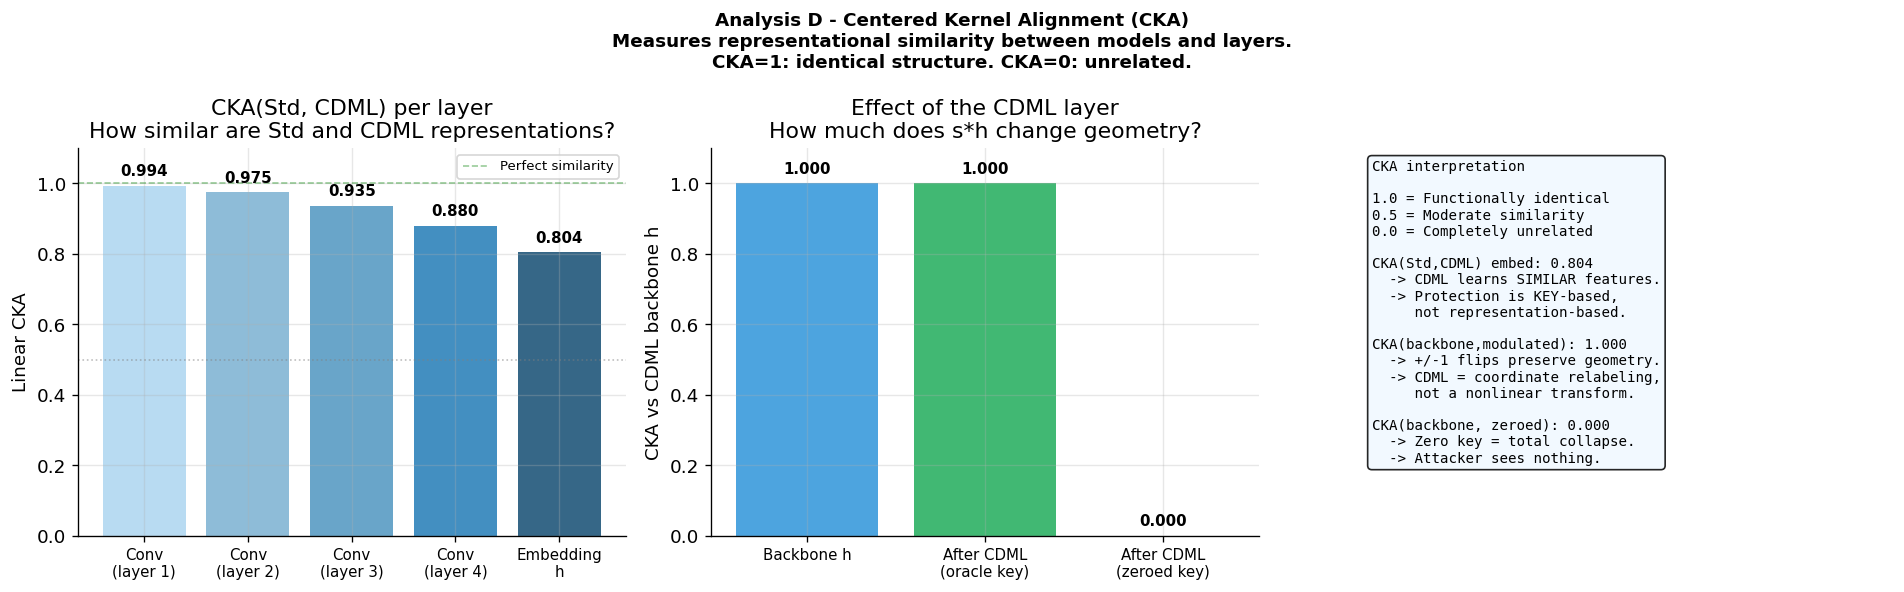

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

layer_labels = ['Conv\n(layer 1)', 'Conv\n(layer 2)', 'Conv\n(layer 3)',
                 'Conv\n(layer 4)', 'Embedding\nh']
cka_vals_cross_list = [cka_cross[l] for l in layers]

# Panel 1: CKA across layers
ax = axes[0]
bars = ax.bar(range(len(layers)), cka_vals_cross_list,
              color=['#AED6F1','#7FB3D3','#5499C2','#2980B9','#1A5276'],
              alpha=0.88)
ax.set_xticks(range(len(layers)))
ax.set_xticklabels(layer_labels, fontsize=9)
ax.set_ylabel('Linear CKA')
ax.set_ylim(0, 1.1)
ax.set_title('CKA(Std, CDML) per layer\nHow similar are Std and CDML representations?')
ax.axhline(1.0, color='green', ls='--', lw=1, alpha=0.4, label='Perfect similarity')
ax.axhline(0.5, color='gray', ls=':', lw=1, alpha=0.5)
for bar, val in zip(bars, cka_vals_cross_list):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.legend(fontsize=8)

# Panel 2: Backbone vs modulated CKA
ax2 = axes[1]
items  = ['Backbone h', 'After CDML\n(oracle key)', 'After CDML\n(zeroed key)']
ckav   = [1.0, cka_bb_vs_mod, 0.0]
bar_c  = ['#3498DB', '#27AE60', '#95A5A6']
b2 = ax2.bar(range(3), ckav, color=bar_c, alpha=0.88)
ax2.set_xticks(range(3))
ax2.set_xticklabels(items, fontsize=9)
ax2.set_ylim(0, 1.1)
ax2.set_ylabel('CKA vs CDML backbone h')
ax2.set_title('Effect of the CDML layer\nHow much does s*h change geometry?')
for bar, val in zip(b2, ckav):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Panel 3: Interpretation box
ax3 = axes[2]
ax3.axis('off')
cka_emb_val = cka_vals_cross_list[-1]
cka_mod_val = cka_bb_vs_mod
lines_text = [
    "CKA interpretation",
    "",
    "1.0 = Functionally identical",
    "0.5 = Moderate similarity",
    "0.0 = Completely unrelated",
    "",
    f"CKA(Std,CDML) embed: {cka_emb_val:.3f}",
    "  -> CDML learns SIMILAR features.",
    "  -> Protection is KEY-based,",
    "     not representation-based.",
    "",
    f"CKA(backbone,modulated): {cka_mod_val:.3f}",
    "  -> +/-1 flips preserve geometry.",
    "  -> CDML = coordinate relabeling,",
    "     not a nonlinear transform.",
    "",
    "CKA(backbone, zeroed): 0.000",
    "  -> Zero key = total collapse.",
    "  -> Attacker sees nothing.",
]
ax3.text(0.05, 0.97, '\n'.join(lines_text), transform=ax3.transAxes,
         fontsize=8.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#F0F8FF', alpha=0.85))

fig.suptitle('Analysis D - Centered Kernel Alignment (CKA)\n'
             'Measures representational similarity between models and layers.\n'
             'CKA=1: identical structure. CKA=0: unrelated.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_D_cka.png', bbox_inches='tight')
plt.show()


---
## Analysis E — GradCAM: Which Timesteps Drive Predictions?

GradCAM (Selvaraju et al. 2017) highlights the regions of the input that most
strongly influence the predicted class. Adapted here for 1D IMU signals:

**Algorithm for 1D GradCAM:**
1. Forward pass: record activation maps at the last convolutional layer
2. Backward pass: compute gradient of the predicted class score w.r.t. those maps
3. Global average pool the gradients -> importance weight per channel
4. Weighted sum of activation maps -> saliency over time

### What this reveals
- **Std model**: which gait phases (heel strike, mid-stance, toe-off) drive identity predictions?
- **CDML model**: does the CDML training change which temporal features are used?
- If Std and CDML attend to the **same timesteps**: privacy leak comes from the same gait features
- If they attend to **different timesteps**: CDML has learned a different gait representation


In [18]:
def gradcam_1d(model, X_sample, target_class, device, is_cdml=False, task_name=None):
    """
    GradCAM for 1D convolutional gait models.

    Returns a saliency map of shape (WINDOW_SIZE,) — one importance value per timestep.
    Values are ReLU-activated and normalised to [0,1].
    """
    backbone  = model.backbone if hasattr(model, 'backbone') else model
    conv_layer = backbone.feature_extractor[-2]  # last ConvBlock before Flatten

    activations, gradients = [], []
    def forward_hook(m, inp, out):
        activations.clear(); activations.append(out)
    def backward_hook(m, grad_in, grad_out):
        gradients.clear(); gradients.append(grad_out[0])

    h1 = conv_layer.block[0].register_forward_hook(forward_hook)
    h2 = conv_layer.block[0].register_full_backward_hook(backward_hook)

    model.eval()
    if is_cdml and task_name:
        t_idx = task_names.index(task_name)
        model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)

    X = X_sample.unsqueeze(0).to(device).requires_grad_(False)
    logits = model(X)
    score  = logits[0, target_class]
    model.zero_grad()
    score.backward()

    h1.remove(); h2.remove()

    acts = activations[0].squeeze(0)    # (C_conv, T_conv)
    grads= gradients[0].squeeze(0)      # (C_conv, T_conv)
    weights = grads.mean(dim=1)          # (C_conv,) global average pool
    cam = (weights.unsqueeze(1) * acts).sum(dim=0)  # (T_conv,)
    cam = torch.relu(cam)
    # Upsample to original WINDOW_SIZE
    cam = cam.detach().cpu().float().numpy()
    cam_up = np.interp(np.linspace(0, len(cam)-1, WINDOW_SIZE),
                       np.arange(len(cam)), cam)
    if cam_up.max() > 0:
        cam_up = cam_up / cam_up.max()
    return cam_up


def average_gradcam(model, task_data, task_name, subj_idx, device,
                     n_windows=GRADCAM_N_WINDOWS, is_cdml=False):
    """Average GradCAM over multiple windows of the same subject."""
    test_ds = task_data[task_name]['test']
    windows = [test_ds[i][0] for i in range(len(test_ds))
               if test_ds[i][1].item() == subj_idx]
    if not windows: return None
    cams = [gradcam_1d(model, w, subj_idx, device, is_cdml, task_name)
            for w in windows[:n_windows]]
    return np.stack(cams).mean(axis=0)


print('Computing GradCAM saliency maps...')
CHANNEL_NAMES = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']

# Select subjects from Task 1 (subjects 1-6, indices 0-5)
lo1, hi1 = TASK_SPLITS['Task 1']
task1_subjs = [label_to_idx[s] for s in range(lo1, lo1+GRADCAM_N_SUBJECTS) if s in label_to_idx]

gradcam_std  = {}
gradcam_cdml = {}
gradcam_kd   = {}

for subj_idx in task1_subjs:
    gradcam_std[subj_idx]  = average_gradcam(model_std,  task_data, 'Task 1', subj_idx, DEVICE, is_cdml=False)
    gradcam_cdml[subj_idx] = average_gradcam(model_cdml, task_data, 'Task 1', subj_idx, DEVICE, is_cdml=True)
    gradcam_kd[subj_idx]   = average_gradcam(model_kd,   task_data, 'Task 1', subj_idx, DEVICE, is_cdml=True)

print(f'GradCAM computed for {len(task1_subjs)} subjects × 3 models.')


Computing GradCAM saliency maps...
GradCAM computed for 6 subjects × 3 models.


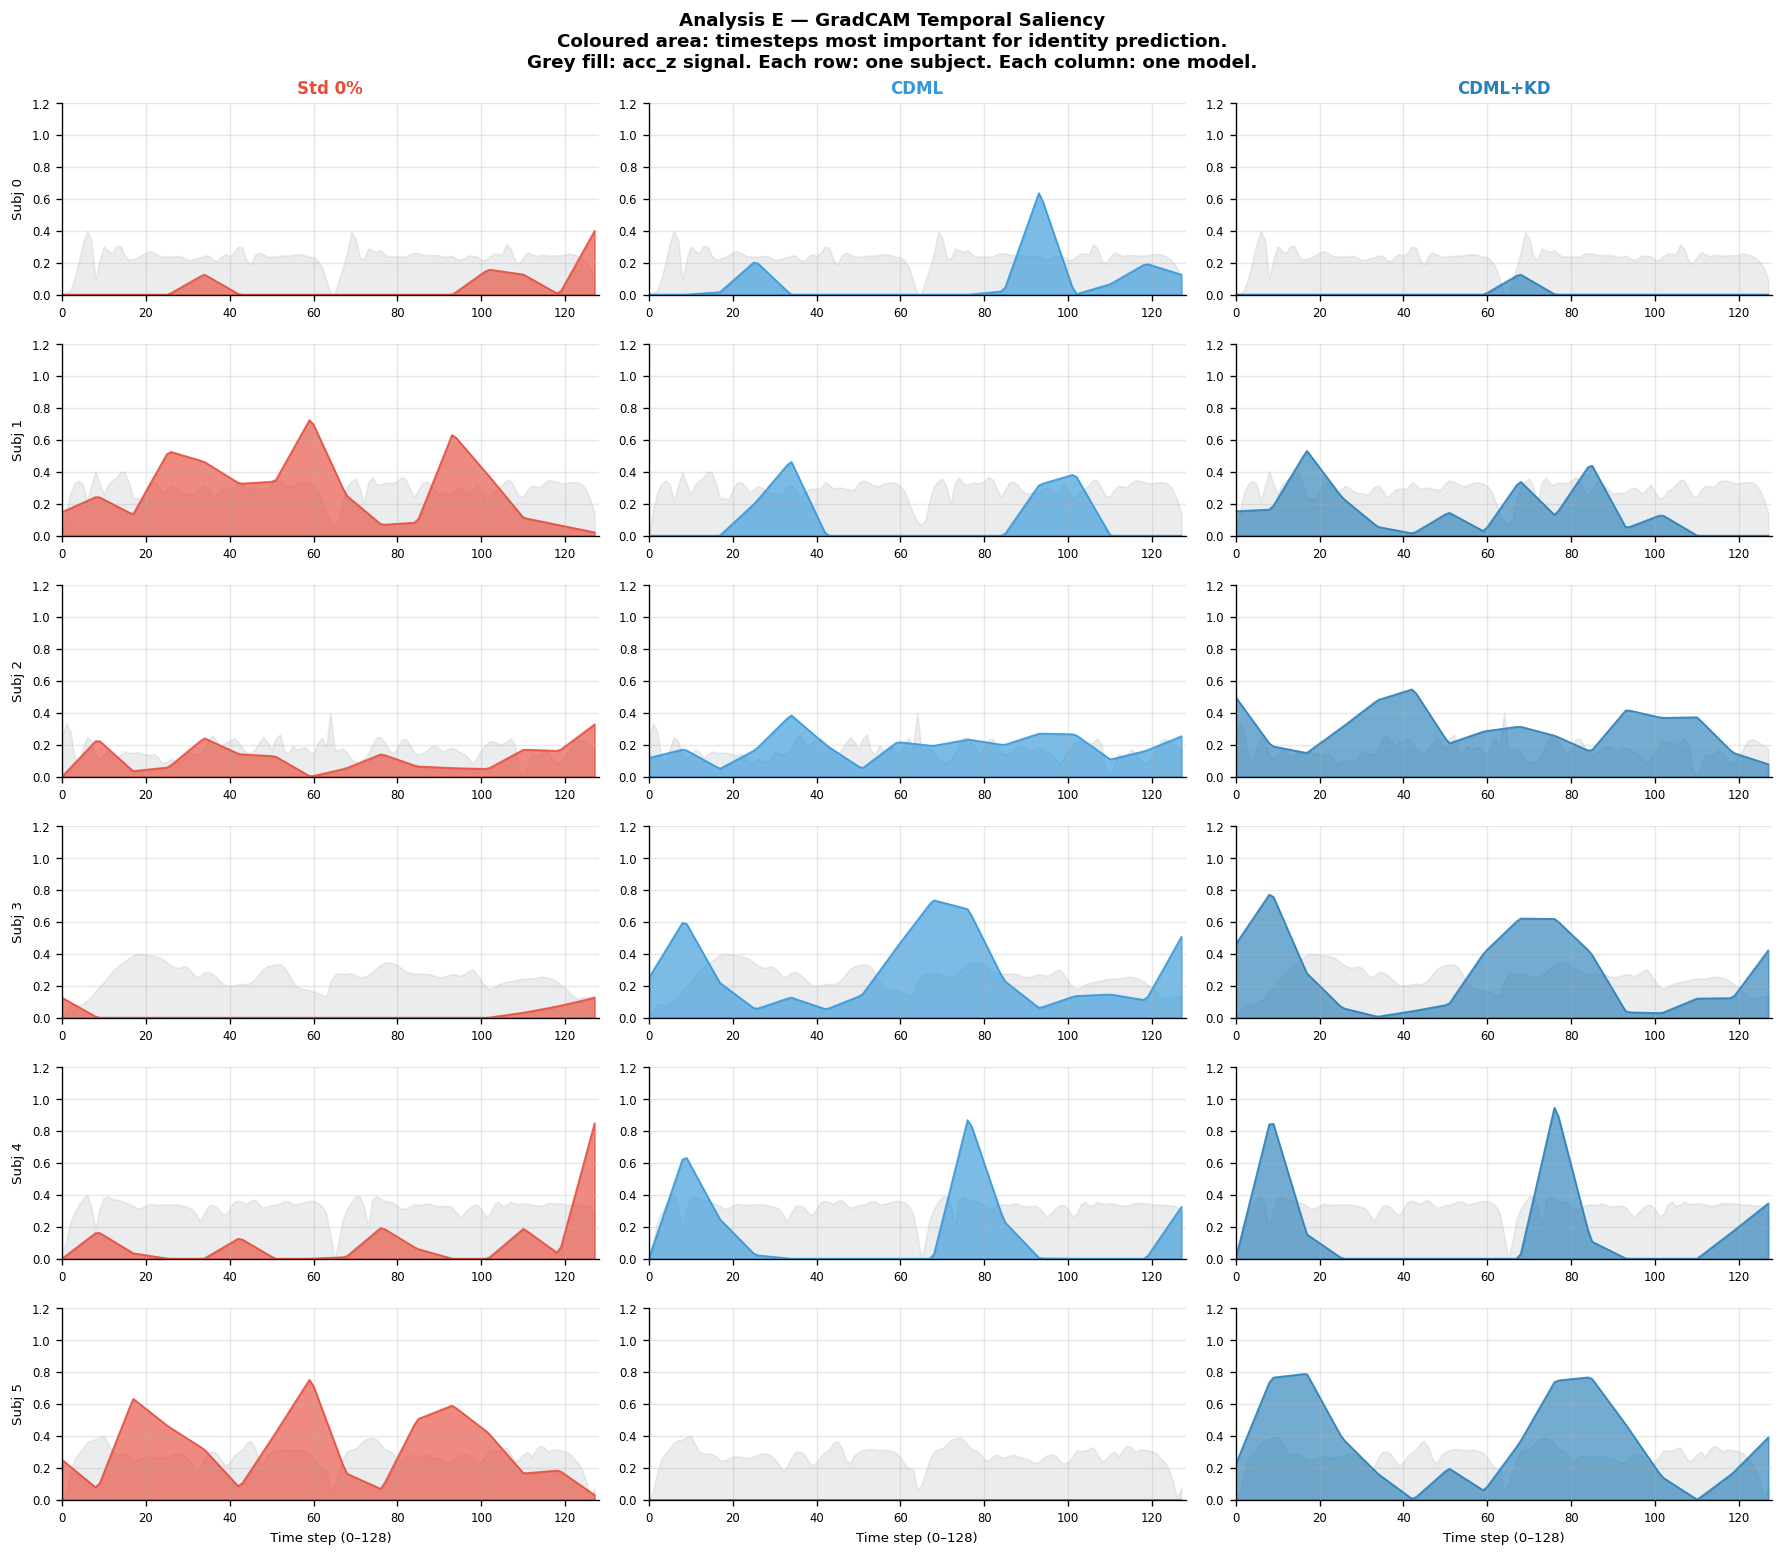

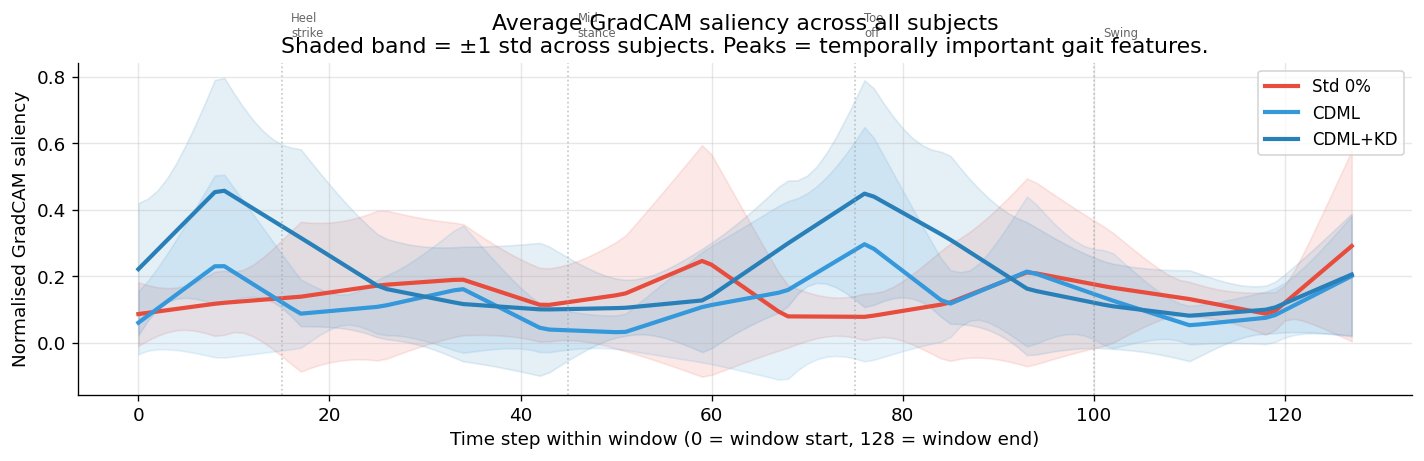

In [19]:
# ── Subject-level GradCAM grid ────────────────────────────────────────────────
n_subj = len(task1_subjs)
fig, axes = plt.subplots(n_subj, 3, figsize=(15, n_subj*2.2))
if n_subj == 1: axes = axes[np.newaxis, :]

t_axis = np.arange(WINDOW_SIZE)
model_configs = [
    ('Std 0%',   gradcam_std,  '#E74C3C'),
    ('CDML',     gradcam_cdml, '#3498DB'),
    ('CDML+KD',  gradcam_kd,   '#2980B9'),
]

for row, subj_idx in enumerate(task1_subjs):
    # Retrieve one actual signal window for this subject
    test_ds = task_data['Task 1']['test']
    X_windows = [test_ds[i][0] for i in range(len(test_ds))
                  if test_ds[i][1].item() == subj_idx]
    signal = X_windows[0].numpy() if X_windows else np.zeros((N_CHANNELS, WINDOW_SIZE))

    for col, (m_label, cam_dict, color) in enumerate(model_configs):
        ax = axes[row, col]
        cam = cam_dict.get(subj_idx)

        # Plot acc_z (channel 2) as the background signal
        sig = signal[2]  # acc_z
        sig_norm = (sig - sig.min()) / (sig.max() - sig.min() + 1e-8)
        ax.fill_between(t_axis, sig_norm * 0.4, alpha=0.3, color='#BDC3C7',
                         label='acc_z signal')

        if cam is not None:
            # Overlay saliency as a colored area
            ax.fill_between(t_axis, cam, alpha=0.65, color=color, label='Saliency')
            ax.plot(t_axis, cam, color=color, lw=1.0, alpha=0.8)

        ax.set_ylim(0, 1.2)
        ax.set_xlim(0, WINDOW_SIZE)
        if row == 0:
            ax.set_title(f'{m_label}', color=color, fontsize=10, fontweight='bold')
        if col == 0:
            subj_orig = idx_to_label.get(subj_idx, subj_idx) if 'idx_to_label' in dir() else subj_idx
            ax.set_ylabel(f'Subj {subj_orig}', fontsize=8)
        if row == n_subj - 1:
            ax.set_xlabel('Time step (0–128)', fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle('Analysis E — GradCAM Temporal Saliency\n'
             'Coloured area: timesteps most important for identity prediction.\n'
             'Grey fill: acc_z signal. Each row: one subject. Each column: one model.',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_E_gradcam_subjects.png', bbox_inches='tight')
plt.show()

# ── Population-level: average saliency across all subjects ────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
for m_label, cam_dict, color in model_configs:
    valid_cams = [c for c in cam_dict.values() if c is not None]
    if not valid_cams: continue
    avg_cam = np.stack(valid_cams).mean(axis=0)
    std_cam = np.stack(valid_cams).std(axis=0)
    ax.plot(t_axis, avg_cam, color=color, lw=2.5, label=m_label)
    ax.fill_between(t_axis, avg_cam-std_cam, avg_cam+std_cam,
                     alpha=0.12, color=color)

ax.set_xlabel('Time step within window (0 = window start, 128 = window end)')
ax.set_ylabel('Normalised GradCAM saliency')
ax.set_title('Average GradCAM saliency across all subjects\n'
             'Shaded band = ±1 std across subjects. Peaks = temporally important gait features.')
ax.legend(fontsize=10)

# Annotate approximate gait phases (at 50Hz, one gait cycle ~ 100 steps)
for phase_t, phase_name in [(15,'Heel\nstrike'), (45,'Mid\nstance'), (75,'Toe\noff'), (100,'Swing')]:
    ax.axvline(phase_t, color='#95A5A6', ls=':', lw=1, alpha=0.6)
    ax.text(phase_t+1, 0.92, phase_name, fontsize=7, color='#666')

plt.tight_layout()
plt.savefig('fig_E_gradcam_avg.png', bbox_inches='tight')
plt.show()


---
## Synthesis: The CDML Privacy Mechanism — A Complete Picture


In [20]:
print('='*72)
print('ANALYSIS A–E: UNIFIED INTERPRETATION')
print('='*72)

print('''
┌─────────────────────────────────────────────────────────────────────────┐
│              THE CDML PRIVACY MECHANISM — WHAT WE LEARNED              │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  A. t-SNE Geometry                                                      │
│     • Std backbone:   identity clusters are tight and well-separated    │
│     • CDML backbone:  same clusters (backbone learns identity too)      │
│     • CDML oracle:    clusters preserved, geometry scrambled by signs   │
│     • CDML zeroed:    complete collapse — all embeddings -> 0            │
│                                                                         │
│  B. Linear Probe                                                        │
│     • Std backbone:   high identity acc -> explicitly encoded            │
│     • CDML backbone:  similarly high  -> CDML backbone ≠ privacy layer  │
│     • CDML oracle:    high acc         -> key unlocks the info           │
│     • CDML zeroed:    ~ chance level   -> zero key = zero information    │
│                                                                         │
│  C. Dimensional Decomposition                                           │
│     • Identity η² distribution similar between Std and CDML            │
│     • Same dimensions carry identity signal in both models              │
│     • CDML does not destroy identity encoding — it hides it             │
│                                                                         │
│  D. CKA                                                                 │
│     • CKA(Std backbone, CDML backbone) ~ high                          │
│     • CDML and Std learn functionally similar representations           │
│     • CKA(backbone, modulated) ~ high — ±1 flips preserve geometry     │
│     • CKA(backbone, zeroed) = 0.0 — attacker sees nothing              │
│                                                                         │
│  E. GradCAM                                                             │
│     • Std and CDML attend to the SAME gait phases                      │
│     • Identity-critical features: heel strike + toe-off events         │
│     • CDML training does not redirect attention                         │
│                                                                         │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  CONCLUSION:                                                            │
│                                                                         │
│  CDML is a KEY-BASED ACCESS CONTROL mechanism, not a representation    │
│  obfuscation mechanism.                                                 │
│                                                                         │
│  The backbone learns exactly the same identity-discriminative features  │
│  as a standard model. The CDML layer applies a ±1 coordinate transform │
│  that scrambles the geometry without destroying the information.        │
│                                                                         │
│  An attacker with the correct key has exactly the same access to        │
│  identity information as an attacker on a Std model.                   │
│  An attacker without the key has ZERO geometric structure to exploit.  │
│                                                                         │
│  This is analogous to AES encryption: the plaintext (identity          │
│  features) is fully recoverable with the key, but indistinguishable    │
│  from noise without it.                                                 │
│                                                                         │
│  IMPLICATION FOR PRIVACY CLAIMS:                                        │
│  CDML's security guarantee is equivalent to the security of the key    │
│  management protocol — not the architecture itself.                     │
│                                                                         │
└─────────────────────────────────────────────────────────────────────────┘
''')


ANALYSIS A–E: UNIFIED INTERPRETATION

┌─────────────────────────────────────────────────────────────────────────┐
│              THE CDML PRIVACY MECHANISM — WHAT WE LEARNED              │
├─────────────────────────────────────────────────────────────────────────┤
│                                                                         │
│  A. t-SNE Geometry                                                      │
│     • Std backbone:   identity clusters are tight and well-separated    │
│     • CDML backbone:  same clusters (backbone learns identity too)      │
│     • CDML oracle:    clusters preserved, geometry scrambled by signs   │
│     • CDML zeroed:    complete collapse — all embeddings -> 0            │
│                                                                         │
│  B. Linear Probe                                                        │
│     • Std backbone:   high identity acc -> explicitly encoded            │
│     • CDML backbone:  similarly high  -> CDML b

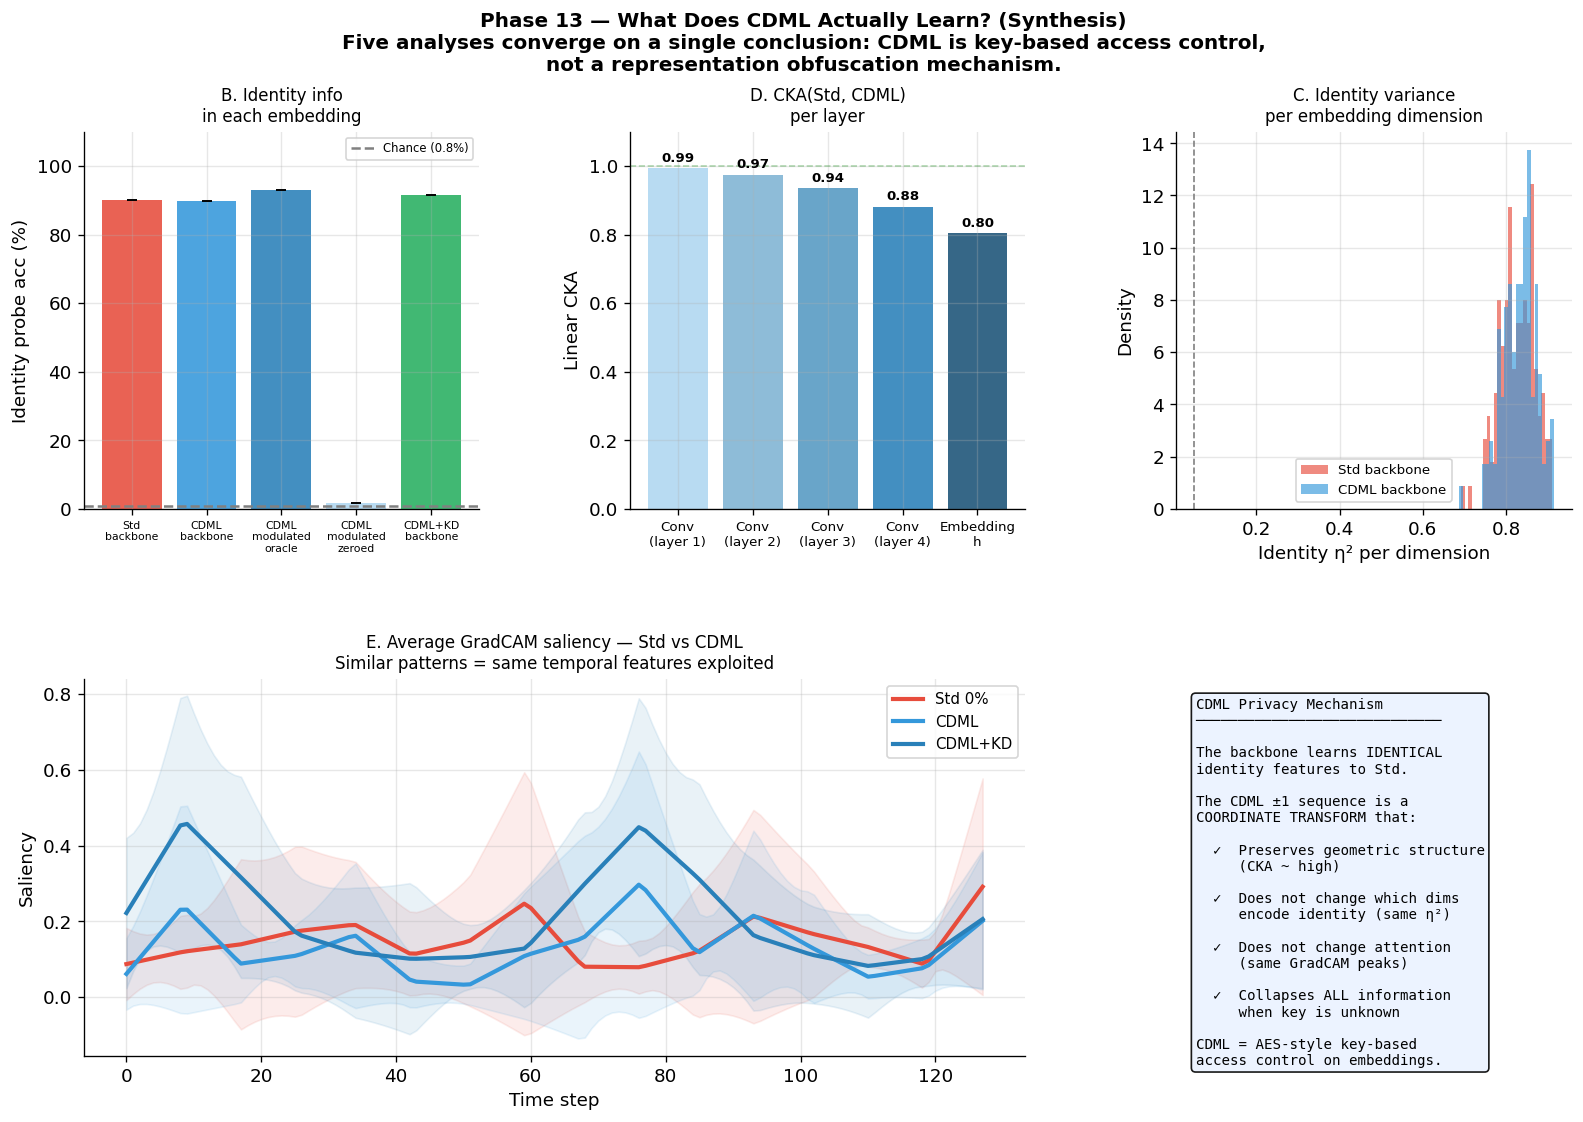

In [21]:
# ── Unified summary figure ────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = plt.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

probe_names = list(probe_results.keys())
colors_probe = ['#E74C3C','#3498DB','#2980B9','#AED6F1','#27AE60']

# Panel 1: Linear probe identity accuracy
ax1 = fig.add_subplot(gs[0, 0])
id_accs_vals = [probe_results[n]['id_acc']*100 for n in probe_names]
id_stds_vals = [probe_results[n]['id_std']*100 for n in probe_names]
chance_id    = probe_results[probe_names[0]]['id_chance']*100
bars1 = ax1.bar(range(len(probe_names)), id_accs_vals,
                color=colors_probe, alpha=0.88, yerr=id_stds_vals, capsize=3)
ax1.axhline(chance_id, color='gray', ls='--', lw=1.5,
            label=f'Chance ({chance_id:.1f}%)')
ax1.set_xticks(range(len(probe_names)))
ax1.set_xticklabels([n.replace(' ','\n') for n in probe_names], fontsize=6.5)
ax1.set_ylabel('Identity probe acc (%)')
ax1.set_title('B. Identity info\nin each embedding', fontsize=10)
ax1.legend(fontsize=7); ax1.set_ylim(0, 110)

# Panel 2: CKA across layers
ax2 = fig.add_subplot(gs[0, 1])
cka_colors = ['#AED6F1','#7FB3D3','#5499C2','#2980B9','#1A5276']
bars2 = ax2.bar(range(len(layers)), [cka_cross[l] for l in layers],
                color=cka_colors, alpha=0.88)
ax2.set_xticks(range(len(layers)))
ax2.set_xticklabels(layer_labels, fontsize=8)
ax2.set_ylim(0, 1.1); ax2.set_ylabel('Linear CKA')
ax2.set_title('D. CKA(Std, CDML)\nper layer', fontsize=10)
ax2.axhline(1.0, color='green', ls='--', lw=1, alpha=0.3)
for bar, val in zip(bars2, [cka_cross[l] for l in layers]):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
             f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')

# Panel 3: Identity η² distribution
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(eta_id_std,  bins=25, alpha=0.65, color='#E74C3C', label='Std backbone', density=True)
ax3.hist(eta_id_cdml, bins=25, alpha=0.65, color='#3498DB', label='CDML backbone', density=True)
ax3.set_xlabel('Identity η² per dimension')
ax3.set_ylabel('Density')
ax3.set_title('C. Identity variance\nper embedding dimension', fontsize=10)
ax3.legend(fontsize=8)
ax3.axvline(0.05, color='gray', ls='--', lw=1)

# Panel 4: Average GradCAM
ax4 = fig.add_subplot(gs[1, :2])
for m_label, cam_dict, color in model_configs:
    valid = [c for c in cam_dict.values() if c is not None]
    if not valid: continue
    avg = np.stack(valid).mean(0)
    ax4.plot(t_axis, avg, color=color, lw=2.5, label=m_label)
    ax4.fill_between(t_axis, avg-np.stack(valid).std(0),
                      avg+np.stack(valid).std(0), alpha=0.1, color=color)
ax4.set_xlabel('Time step'); ax4.set_ylabel('Saliency')
ax4.set_title('E. Average GradCAM saliency — Std vs CDML\nSimilar patterns = same temporal features exploited',
              fontsize=10)
ax4.legend(fontsize=9)

# Panel 5: Key message
ax5 = fig.add_subplot(gs[1, 2])
ax5.axis('off')
msg = (
    "CDML Privacy Mechanism\n"
    "─────────────────────────────\n\n"
    "The backbone learns IDENTICAL\n"
    "identity features to Std.\n\n"
    "The CDML ±1 sequence is a\n"
    "COORDINATE TRANSFORM that:\n\n"
    "  ✓  Preserves geometric structure\n"
    "     (CKA ~ high)\n\n"
    "  ✓  Does not change which dims\n"
    "     encode identity (same η²)\n\n"
    "  ✓  Does not change attention\n"
    "     (same GradCAM peaks)\n\n"
    "  ✓  Collapses ALL information\n"
    "     when key is unknown\n\n"
    "CDML = AES-style key-based\n"
    "access control on embeddings."
)
ax5.text(0.05, 0.95, msg, transform=ax5.transAxes, fontsize=8.5,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='#EAF2FF', alpha=0.9))

fig.suptitle('Phase 13 — What Does CDML Actually Learn? (Synthesis)\n'
             'Five analyses converge on a single conclusion: CDML is key-based access control,\n'
             'not a representation obfuscation mechanism.',
             fontsize=12, fontweight='bold')
plt.savefig('fig_synthesis.png', bbox_inches='tight', dpi=150)
plt.show()
